<div align="center">

<h1>Trabalho – SDM (2025.2)</h1>  
<h3>Prof. Cristiano Fernandes</h3>  

<br>

<h3>Alunos:</h3>
<h4>Alessandra Malizia – 2512127</h4>
<h4>Luiz Felipe Rodrigues – 2511879</h4>

</div>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import datetime as dt

from scipy.optimize import minimize
from scipy.special import expit, logit, gammaln
from scipy.stats import probplot, norm, poisson, nbinom, uniform

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

In [2]:
def plot_forecast(y_obs, forecast_mean, forecast_ic, title=None):
    """
    Plota série observada e previsão k-passos com intervalo de confiança.
    """
    T = len(y_obs)
    k = len(forecast_mean)
    forecast_idx = np.arange(T, T + k)

    plt.figure(figsize=(12, 5))
    plt.plot(np.arange(T), y_obs, label='Série Observada', lw=1.5, color='black')
    plt.plot(forecast_idx, forecast_mean, label='Previsão', lw=2, color='tab:blue')
    plt.fill_between(forecast_idx, forecast_ic[0], forecast_ic[1], color='tab:blue', alpha=0.3, label='IC 95%')

    plt.axvline(T - 1, color='grey', linestyle='--', lw=1)
    plt.xlabel("Tempo")
    plt.ylabel("Contagem")
    title = f"Previsão {k}-passos à frente" if title is None else title
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Modelos GAS Hurdle

## 1. GAS Hurdle Poisson (GHP)

Diferentemente das distribuições Poisson e Binomial Negativa (NB) padrão — nas quais a probabilidade de observar zero é função da média e variância —, nas distribuições aumentadas para zeros (zero‑augmented), como a hurdle Poisson, a probabilidade de zero surge de um processo separado.

Na hurdle Poisson (HP), primeiro ocorre um **ensaio de Bernoulli**, que gera um zero com probabilidade  
$$
\pi_{t|t-1}.
$$

Se ocorrer “falha” no Bernoulli, o valor positivo é amostrado de uma **Poisson truncada em zero**.

A função de massa de probabilidade da HP dinâmica é:

$$
p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1}) =
\begin{cases}
\pi_{t|t-1}, & y_t = 0, \\[8pt]
(1 - \pi_{t|t-1})
\dfrac{\lambda_{t|t-1}^{y_t} e^{-\lambda_{t|t-1}}}{y_t! \left(1 - e^{-\lambda_{t|t-1}}\right)}, 
& y_t > 0.
\end{cases}
$$

com  
- $\lambda_{t|t-1} > 0$,  
- $\pi_{t|t-1} \in (0,1)$.

### 1.1 Média e Variância

**Média:**

$$
\mathbb{E}_{t-1}[y_t] = 
\frac{\lambda_{t|t-1}}{1 - e^{-\lambda_{t|t-1}}}(1 - \pi_{t|t-1})
$$

**Variância:**

$$
\operatorname{Var}_{t-1}[y_t] =
\lambda_{t|t-1}(1 - \pi_{t|t-1})
\frac{1}{1 - e^{-\lambda_{t|t-1}}}
\left[
1 +
\frac{\lambda_{t|t-1} \pi_{t|t-1}}{1 - e^{-\lambda_{t|t-1}}} - \frac{\lambda_{t|t-1}}{e^{\lambda_{t|t-1}}(1 - e^{-\lambda_{t|t-1}})}
\right]
$$

### 1.2 Dinâmica dos parâmetros

Faremos o passo a passo na derivação das dinâmicas do modelo GHP, calcularemos tanto com a função _link_ identidade, como também reparametrizada conforme as funções _link_ abaixo

$$
h_1(\pi_{t|t-1}) = \tilde{\pi}_{t|t-1} = \ln\left( \frac{\pi_{t|t-1}}{1 - \pi_{t|t-1}} \right), \quad
h_2(\lambda_{t|t-1}) = \tilde{\lambda}_{t|t-1} = \ln(\lambda_{t|t-1})
$$

#### 1.2.1 Gradiente da função de probabilidade condicional

Como visto, a função de probabilidade condicional é uma mistura:

$$
\ln(p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) - \lambda_{t|t-1} + y_t \ln(\lambda_{t|t-1}) - \ln(y_t!) - \ln(1 - \exp(-\lambda_{t|t-1})), & \text{se } y_t > 0
\end{cases}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\nabla_{y_t = 0} =
\begin{bmatrix}
\nabla_{y_t = 0}^{\pi_{t|t-1}} \\
\nabla_{y_t = 0}^{\lambda_{t|t-1}}
\end{bmatrix}
= \begin{bmatrix}
\frac{1}{\pi_{t|t-1}} \\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\nabla_{y_t > 0} =
\begin{bmatrix}
\nabla_{y_t > 0}^{\pi_{t|t-1}} \\
\nabla_{y_t > 0}^{\lambda_{t|t-1}}
\end{bmatrix}
=\begin{bmatrix}
\frac{-1}{1 - \pi_{t|t-1}} \\\\
\frac{y_t - \lambda_{t|t-1}}{\lambda_{t|t-1}} - \frac{e^{-\lambda_{t|t-1}}}{1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

#### 1.2.2 Informação de Fisher

Para a informação de Fisher, temos que

$$
\mathcal{I}_{t|t-1} = \mathbb{E}_{t-1}
\left[
\begin{bmatrix}
(\nabla^{\pi_{t|t-1}})^2 & \nabla^{\pi_{t|t-1}} \nabla^{\lambda_{t|t-1}} \\
\nabla^{\lambda_{t|t-1}} \nabla^{\pi_{t|t-1}} & (\nabla^{\lambda_{t|t-1}})^2
\end{bmatrix}
\right]
=
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \frac{ (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} ] }{(1 - e^{-\lambda_{t|t-1}})^2 \lambda_{t|t-1}}
\end{bmatrix}
$$

#### 1.2.3 Jacobiana das funções _link_

Dadas as funções $h_1$ e $h_2$ definidas acima, temos que 

$$
\tilde{h}_{t|t-1} =
\begin{bmatrix}
\frac{\partial h_1}{\partial \pi_{t|t-1}} & 0 \\\\
0 & \frac{\partial h_2}{\partial \lambda_{t|t-1}}
\end{bmatrix} = 
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \frac{1}{\lambda_{t|t-1}}
\end{bmatrix}
$$

Com isso, a inversa de $\tilde{h}_{t|t-1}$ é dada por

$$
\tilde{h}_{t|t-1}^{-1} =
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \lambda_{t|t-1}
\end{bmatrix}
$$

#### 1.2.4 _Score_ do GHP

Encontramos $\nabla_{y_t = 0}$ e $\nabla_{y_t > 0}$, que foram calculadas com base na função _link_ identidade. Agora encontraremos $\tilde{\nabla}_{y_t = 0}$ e $\tilde{\nabla}_{y_t > 0}$. para que possamos encontrar o _score_ e finalmente chegarmos à dinâmica dos parâmetros.

- Para $y_t = 0$:

$$
\tilde{\nabla}_{y_t = 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t = 0} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\\\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{\nabla}_{y_t > 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t > 0} =
\begin{bmatrix}
- \pi_{t|t-1} \\\\
y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

Abaixo, encontramos a Informação de Fischer reparametrizada:

$$
\tilde{\mathcal{I}}_{t|t-1} =
\tilde{h}_{t|t-1}^{-1} \mathcal{I}_{t|t-1} \tilde{h}_{t|t-1}^{-1}
=
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \frac{ \lambda_{t|t-1} (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{(1 - e^{-\lambda_{t|t-1}})^2}
\end{bmatrix}
$$

Com isso, podemos encontrar os _scores_, conforme equação geral abaixo

$$
\tilde{s}_{t|t-1}
=
\left( \tilde{\mathcal{I}}_{t|t-1} \right)^{-d} \tilde{\nabla}_{t|t-1}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\tilde{\nabla}_{t|t-1}^{(y=0)} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\
0
\end{bmatrix}
\qquad
\tilde{\mathcal{I}}_{t|t-1} =
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\
0 & \mathcal{I}_{\lambda}
\end{bmatrix}
$$

Logo, o score reparametrizado para $d=0$ é:

$$
\tilde{s}_{t|t-1}^{(y=0)} =
\begin{bmatrix}
\displaystyle 1-\pi_{t|t-1} \\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{\nabla}_{t|t-1}^{(y>0)} =
\begin{bmatrix}
- \pi_{t|t-1} \\
y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

e

$$
\tilde{\mathcal{I}}_{t|t-1} =
\tilde{h}_{t|t-1}^{-1} \mathcal{I}_{t|t-1} \tilde{h}_{t|t-1}^{-1}
=
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \frac{ \lambda_{t|t-1} (1 - \pi_{t|t-1}) [ 1 - e^{-\lambda_{t|t-1}} - \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{(1 - e^{-\lambda_{t|t-1}})^2}
\end{bmatrix}
$$

O score reparametrizado torna-se, para $d=0$:

$$
\tilde{s}_{t|t-1}^{(y>0)} =
\begin{bmatrix}
\displaystyle - \pi_{t|t-1} \\
\displaystyle y_t - \lambda_{t|t-1} - \frac{ \lambda_{t|t-1} e^{-\lambda_{t|t-1}} }{ 1 - e^{-\lambda_{t|t-1}}}
\end{bmatrix}
$$

Com isso, utilizamos os scores reparametrizados acima para atualizar $\tilde{\pi}_{t|t-1}$ e $\tilde{\lambda}_{t|t-1}$ via uma estrutura autoregressiva do tipo AR(1) com inovação do tipo GAS.

##### 1.2.4.1 Probabilidade de zero — $\tilde{\pi}_{t|t-1}$

$$
\tilde{\pi}_{t+1|t}
=
\delta_\pi
+
\beta_\pi \cdot \tilde{\pi}_{t|t-1}
+
\rho_\pi \cdot \tilde{s}_{\pi,t|t-1}
$$

onde:

- $\delta_\pi$: constante
- $\beta_\pi$: persistência
- $\rho_\pi$: peso do score
- $\tilde{s}_{\pi,t|t-1}$: componente do score referente a $\pi$

##### 1.2.4.2 Intensidade — $\tilde{\lambda}_{t|t-1}$

$$
\tilde{\lambda}_{t+1|t}
=
\delta_\lambda
+
\beta_\lambda \cdot \tilde{\lambda}_{t|t-1}
+
\rho_\lambda \cdot \tilde{s}_{\lambda,t|t-1}
$$

onde:

- $\tilde{s}_{\lambda,t|t-1}$: componente do score referente a $\lambda$

### 1.3 Simulação

Abaixo simularemos o GHP.

In [3]:
def sigmoid(x):
    return expit(x)

def clip_logit(x, bounds=(-6, 6)):
    return np.clip(x, *bounds)

def clip_exp(x, bounds=(-5, 4)):
    return np.clip(np.exp(x), np.exp(bounds[0]), np.exp(bounds[1]))

In [4]:
def score_ghp(y, lambda_, pi):
    """
    Calcula o score reparametrizado para o modelo GAS Hurdle Poisson (GHP).
    Retorna os dois componentes: score_pi, score_lambda
    """
    if y == 0:
        score_pi = 1 - pi
        score_lambda = 0.0
    else:
        numer = lambda_ * np.exp(-lambda_)
        denom = 1 - np.exp(-lambda_)
        adjustment = lambda_ + numer / denom

        score_pi = -pi
        score_lambda = y - adjustment

    return score_pi, score_lambda

In [5]:
def filter_ghp(params, y, loglam_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    """
    Aplica o filtro GAS Hurdle Poisson (GHP), retornando caminhos filtrados.
    """
    # delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params
    lambda_tilde0 = params['lambda_tilde']
    pi_tilde0     = params['pi_tilde']
    delta_lambda  = params['delta_lambda']
    beta_lambda   = params['beta_lambda']
    rho_lambda    = params['rho_lambda']
    delta_pi      = params['delta_pi']
    beta_pi       = params['beta_pi']
    rho_pi        = params['rho_pi']

    T = len(y)
    lambda_tilde = np.zeros(T)
    pi_tilde     = np.zeros(T)
    lambda_t     = np.zeros(T)
    pi_t         = np.zeros(T)
    score_lambda = np.zeros(T)
    score_pi     = np.zeros(T)

    lambda_tilde[0] = lambda_tilde0
    pi_tilde[0]     = pi_tilde0

    for t in range(T):
        lambda_t[t] = np.exp(lambda_tilde[t])
        pi_t[t]     = expit(pi_tilde[t])

        if t < T - 1:
            # Score reparametrizado
            s_tilde_pi, s_tilde_lambda = score_ghp(y[t], lambda_t[t], pi_t[t])

            score_pi[t]     = s_tilde_pi
            score_lambda[t] = s_tilde_lambda

            # Atualização GAS(1,1)
            lambda_tilde[t+1] = np.clip(delta_lambda + rho_lambda * score_lambda[t] + beta_lambda * lambda_tilde[t], *loglam_bounds)
            pi_tilde[t+1]     = np.clip(delta_pi     + rho_pi     * score_pi[t]     + beta_pi     * pi_tilde[t],     *logitpi_bounds)

    return lambda_t, pi_t, lambda_tilde, pi_tilde, score_lambda, score_pi

In [6]:
def simulate_ghp(n_obs, params, seed=None, lambda_max=50):
    """
    Simula uma série GHP com parâmetros dados.
    """
    if seed is not None:
        np.random.seed(seed)

    # delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params
    lambda_tilde = params['lambda_tilde']
    pi_tilde     = params['pi_tilde']
    delta_lambda = params['delta_lambda']
    beta_lambda  = params['beta_lambda']
    rho_lambda   = params['rho_lambda']
    delta_pi     = params['delta_pi']
    beta_pi      = params['beta_pi']
    rho_pi       = params['rho_pi']

    y = np.zeros(n_obs, dtype=int)
    lambda_t = np.zeros(n_obs)
    pi_t     = np.zeros(n_obs)
    f_lambda = lambda_tilde
    f_pi     = pi_tilde

    tolerancia = 0.001

    for t in range(n_obs):
        lam = np.clip(np.exp(f_lambda), tolerancia, lambda_max)
        pi0 = expit(f_pi)

        lambda_t[t] = lam
        pi_t[t]     = np.clip(pi0, tolerancia, 1 - tolerancia)

        u = np.random.rand()
        if u < pi_t[t]:
            y[t] = 0
        else:
            while True:
                z = np.random.poisson(lam)
                if z > 0:
                    y[t] = z
                    break

        score_pi, score_lambda = score_ghp(y[t], lam, pi_t[t])

        f_lambda = np.clip(delta_lambda + rho_lambda * score_lambda + beta_lambda * f_lambda, -5, 4)
        f_pi     = np.clip(delta_pi     + rho_pi     * score_pi     + beta_pi     * f_pi,     -6, 6)

    return y, lambda_t, pi_t

In [7]:
n_obs = 300
series_list = []
param_list = []

rng = np.random.default_rng(42)

for i in range(5):
    params_i = {
        'lambda_tilde': round(rng.uniform(0, 1), 2),
        'pi_tilde': round(rng.uniform(0, 0.4), 2),
        'delta_lambda': round(rng.uniform(-0.5, 0.5), 2),
        'beta_lambda': round(rng.uniform(-0.95, 0.95), 2),
        'rho_lambda':  round(rng.uniform(0.5, 0.95), 2),
        'delta_pi': round(rng.uniform(-0.5, 0.5), 2),
        'beta_pi': round(rng.uniform(-0.95, 0.95), 2),
        'rho_pi':  round(rng.uniform(0.5, 0.95), 2),
    }

    y_i, lam_i, pi_i = simulate_ghp(n_obs, params_i, seed=123 + i)
    series_list.append(y_i)
    param_list.append(params_i)

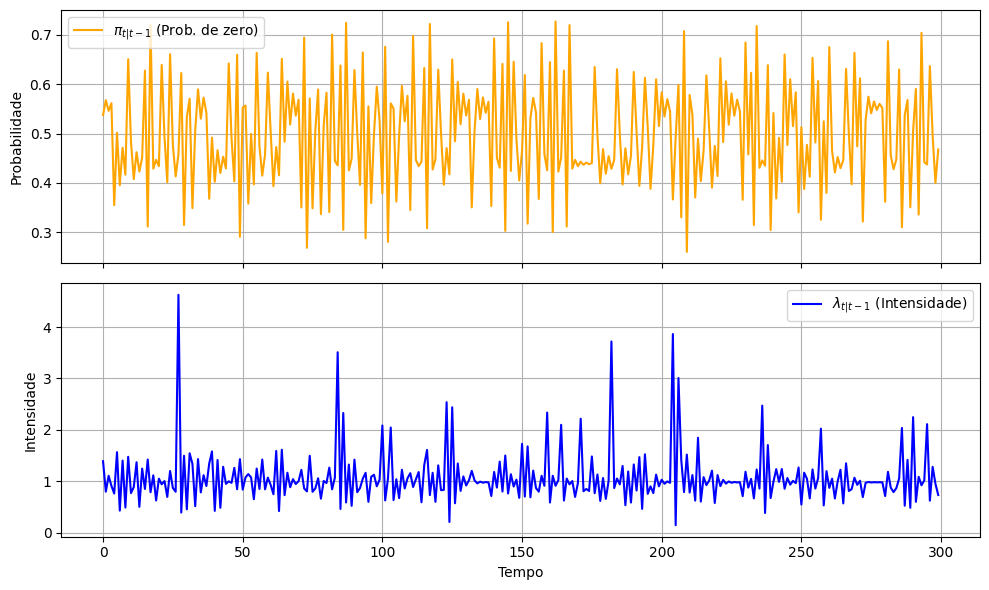

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(pi_i, label=r'$\pi_{t|t-1}$ (Prob. de zero)', color='orange')
ax[0].set_ylabel('Probabilidade')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(lam_i, label=r'$\lambda_{t|t-1}$ (Intensidade)', color='blue')
ax[1].set_ylabel('Intensidade')
ax[1].set_xlabel('Tempo')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

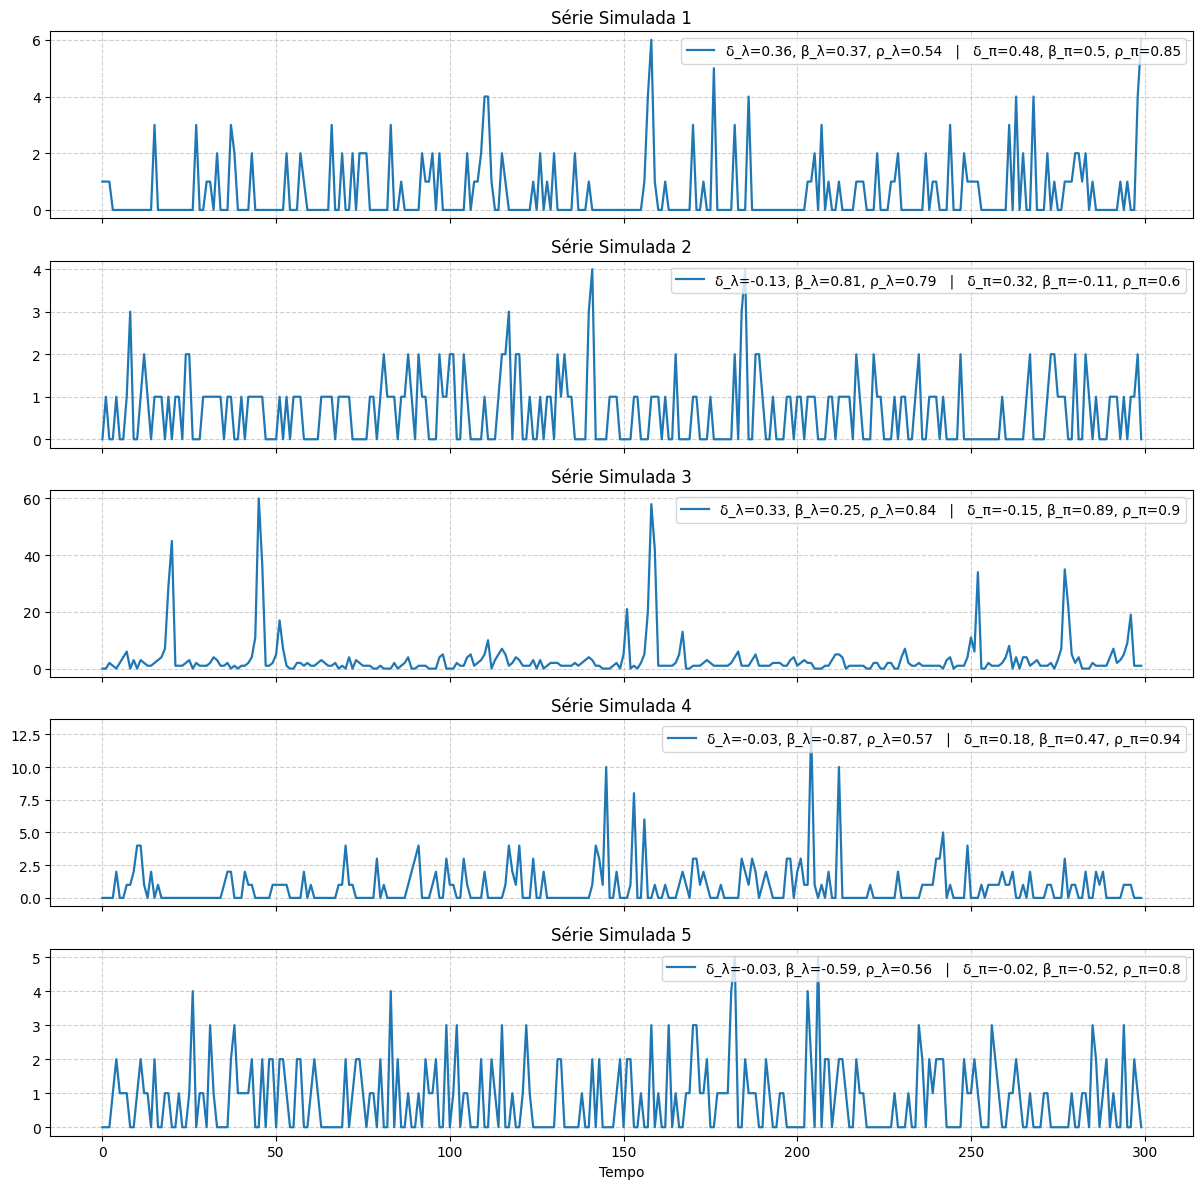

In [9]:
fig, axs = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

for i in range(5):
    s = series_list[i]
    p = param_list[i]

    axs[i].plot(s, lw=1.6)

    legend_text = (
        f"δ_λ={p['delta_lambda']}, β_λ={p['beta_lambda']}, ρ_λ={p['rho_lambda']}   |   "
        f"δ_π={p['delta_pi']}, β_π={p['beta_pi']}, ρ_π={p['rho_pi']}"
    )

    axs[i].legend([legend_text], loc='upper right')
    axs[i].set_title(f"Série Simulada {i+1}")
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tempo")
plt.tight_layout()
plt.show()

### 1.4 Ajustando modelo GHP

Vimos que o log da probabilidade no modelo GHP é dada por

$$
\ln(p(y_t \mid Y_{t-1}, \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) - \lambda_{t|t-1} + y_t \ln(\lambda_{t|t-1}) - \ln(y_t!) - \ln(1 - \exp(-\lambda_{t|t-1})), & \text{se } y_t > 0
\end{cases}
$$

Com isso, a log-verossimilhança do modelo GHP é dada pelo seguinte somatório

$$
\ell(\theta)
=
\sum_{t=1}^T \ln p(y_t \mid \mathcal{F}_{t-1}, \theta)
$$

Além disso, os parâmetros $\pi_{t|t-1}$ e $\lambda_{t|t-1}$, cuja dinâmica definimos anteriormente, tem a seguinte recorrência

$$
\tilde{\pi}_{t+1|t} = \delta_\pi + \beta_\pi \cdot \tilde{\pi}_{t|t-1} + \rho_\pi \cdot \tilde{s}_{\pi, t|t-1}
\quad \Rightarrow \quad
\pi_{t|t-1} = \text{expit}(\tilde{\pi}_{t|t-1})
$$

$$
\tilde{\lambda}_{t+1|t} = \delta_\lambda + \beta_\lambda \cdot \tilde{\lambda}_{t|t-1} + \rho_\lambda \cdot \tilde{s}_{\lambda, t|t-1}
\quad \Rightarrow \quad
\lambda_{t|t-1} = \exp(\tilde{\lambda}_{t|t-1})
$$

Com isso, o vetor de parâmetros estimado por MLE é:

$$
\Theta =
\left\{
\tilde{\lambda}_{1|0}, \,
\tilde{\pi}_{1|0}, \,
\delta_\pi, \,
\beta_\pi, \,
\rho_\pi, \,
\delta_\lambda, \,
\beta_\lambda, \,
\rho_\lambda
\right\}
\in
\mathbb{R}^6
$$

Com as restrições usuais:

- $\beta_\pi, \beta_\lambda \in (-1, 1)$
- $\rho_\pi, \rho_\lambda > 0$

In [10]:
def ghp_scores(y, lam, pi):
    """
    Retorna os scores reparametrizados (tilde-s) do modelo GHP.
    Score é um VETOR de dimensão 2:
        [score_pi , score_lambda]
    conforme fórmulas (18) e (19)
    """
    if y == 0:
        score_pi = 1 - pi
        score_lam = 0.0
    else:
        # Poisson truncada
        trunc_factor = lam + lam * np.exp(-lam) / (1 - np.exp(-lam))
        score_pi = -pi
        score_lam = y - trunc_factor

    return score_pi, score_lam

In [11]:
def neg_loglik_ghp(params, y):
    """
    Log-verossimilhança negativa do modelo GAS Hurdle Poisson (GHP)
    com a nova parametrização:
        delta_lambda, beta_lambda, rho_lambda,
        delta_pi,     beta_pi,     rho_pi
    """
    # desempacotar parâmetros
    lambda_tilde, pi_tilde, delta_lambda, beta_lambda, rho_lambda, delta_pi, beta_pi, rho_pi = params

    # -------------------------------------------
    # 1. Restrições estruturais
    # -------------------------------------------
    if not (-1 < beta_lambda < 1 and -1 < beta_pi < 1):
        return np.inf

    if not (rho_lambda > 0 and rho_pi > 0):
        return np.inf

    # -------------------------------------------
    # 2. Executar o filtro para obter lambda_t|t-1 e pi_t|t-1
    # -------------------------------------------
    params_dict = {
        'lambda_tilde': lambda_tilde,
        'pi_tilde': pi_tilde,
        'delta_lambda': delta_lambda,
        'beta_lambda': beta_lambda,
        'rho_lambda': rho_lambda,
        'delta_pi': delta_pi,
        'beta_pi': beta_pi,
        'rho_pi':  rho_pi,
    }
    lambda_t, pi_t, _, _, _, _ = filter_ghp(params_dict, y)

    # -------------------------------------------
    # 3. Construção da log-verossimilhança
    # -------------------------------------------
    loglik = 0.0
    T = len(y)

    for t in range(T):
        lam = lambda_t[t]
        pi0 = pi_t[t]

        if y[t] == 0:
            # massa total do zero na hurdle Poisson
            loglik += np.log(pi0)
        else:
            # log pmf Poisson
            pois = y[t] * np.log(lam) - lam - gammaln(y[t] + 1)

            # ajustar truncação em zero
            pois_trunc = pois - np.log(1 - np.exp(-lam))

            # log-likelihood final
            loglik += np.log(1 - pi0) + pois_trunc

    return -loglik

In [12]:
serie_indice = 0
y_obs = series_list[serie_indice]
n = len(y_obs)
parametros_originais = param_list[serie_indice]

# Chute inicial sensato
x0 = np.array([0.1, 0.1, 0.1, 0.1, 0.9, 0.1, 0.1, 0.9])

bounds = [
    (-2, 2),
    (-2, 2),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1)
]

result = minimize(
    neg_loglik_ghp,
    x0,
    args=(y_obs,),
    method="L-BFGS-B",
    bounds=bounds
)

C:\Users\aless\Desktop\Codes\venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


### 1.5 Resultados

#### 1.5.1 Comparando os parâmetros

Abaixo, mostramos os valores originais e estimados dos parametros.

In [13]:
theta_hat = result.x
print("\n==== Parâmetros Estimados (MLE) ====")
print(f"delta_lambda={theta_hat[2]:.4f}, beta_lambda={theta_hat[3]:.4f}, rho_lambda={theta_hat[4]:.4f}")
print(f"delta_pi={theta_hat[5]:.4f}, beta_pi={theta_hat[6]:.4f}, rho_pi={theta_hat[7]:.4f}")

print()
print("-" * 65)

print("\n==== Parâmetros Originais ====")
print(f"delta_lambda={parametros_originais['delta_lambda']:.4f}, beta_lambda={parametros_originais['beta_lambda']:.4f}, rho_lambda={parametros_originais['rho_lambda']:.4f}")
print(f"delta_pi={parametros_originais['delta_pi']:.4f}, beta_pi={parametros_originais['beta_pi']:.4f}, rho_pi={parametros_originais['rho_pi']:.4f}")


==== Parâmetros Estimados (MLE) ====
delta_lambda=0.1000, beta_lambda=0.1000, rho_lambda=0.9000
delta_pi=0.1000, beta_pi=0.1000, rho_pi=0.9000

-----------------------------------------------------------------

==== Parâmetros Originais ====
delta_lambda=0.3600, beta_lambda=0.3700, rho_lambda=0.5400
delta_pi=0.4800, beta_pi=0.5000, rho_pi=0.8500


#### 1.6.2 Mostrando os resultados

Seguem os gráficos para comparaçãos dos resultados.

In [14]:
theta_hat_dict = {
    'lambda_tilde': theta_hat[0],
    'pi_tilde': theta_hat[1],
    'delta_lambda': theta_hat[2],
    'beta_lambda': theta_hat[3],
    'rho_lambda': theta_hat[4],
    'delta_pi': theta_hat[5],
    'beta_pi': theta_hat[6],
    'rho_pi':  theta_hat[7],
}

lambda_hat, pi_hat, f_lambda_hat, f_pi_hat, score_lambda, score_pi = filter_ghp(theta_hat_dict, y_obs)

In [15]:
def insample_forecast_ghp(y, lambda_t, pi_t, title='In-sample: Observado vs E[y|t-1]'):
    """
    Calcula a esperança condicional in-sample da Hurdle Poisson segundo
    E_{t-1}[y_t] = (lambda_t / (1 - exp(-lambda_t))) * (1 - pi_t)
    Plota observado vs previsão e retorna as métricas RMSE, MAE e MAPE.
    """

    exp_neg_lam = np.exp(-np.clip(lambda_t, None, 700))
    denom = 1.0 - exp_neg_lam
    denom = np.maximum(denom, 1e-8)

    # valor esperado
    mu_trunc = lambda_t / denom
    yhat = mu_trunc * (1.0 - pi_t)

    # métricas
    resid = y - yhat
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    metrics = {'rmse': float(rmse), 'mae': float(mae)}

    # plot
    fig, ax = plt.subplots(figsize=(12,4.5))
    ax.plot(y, label='Observado (y)', linewidth=1, alpha=0.9)
    ax.plot(yhat, label=r'E$_{t-1}[y_t]$', linewidth=1.4, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.set_ylabel('Contagem')
    ax.legend()
    ax.grid(alpha=0.25)

    # mostrar métricas no gráfico
    textstr = (f"RMSE = {metrics['rmse']:.3f}\n"
               f"MAE  = {metrics['mae']:.3f}\n")
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

    return yhat, metrics

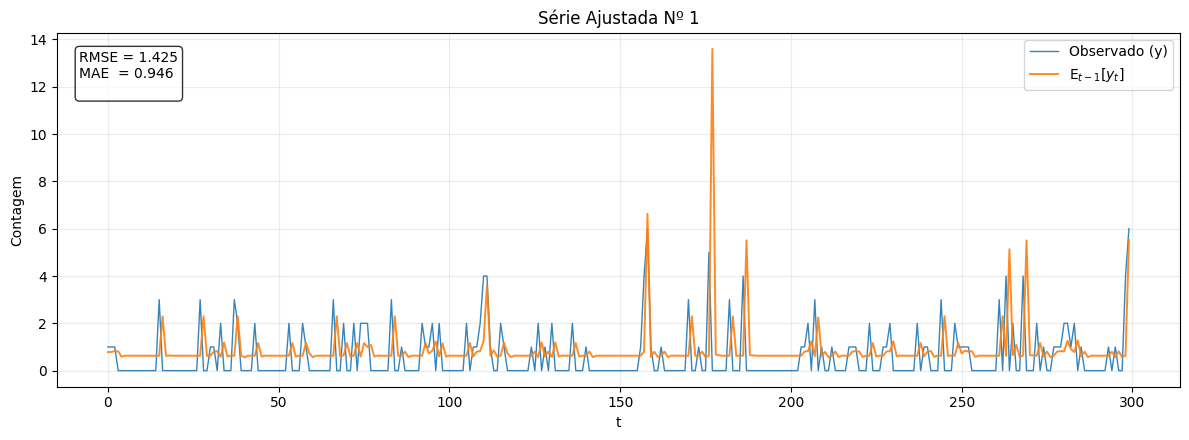

In [16]:
y_hat, metrics = insample_forecast_ghp(
    y_obs, lambda_hat, pi_hat,
    title=f"Série Ajustada Nº {serie_indice+1}"
)

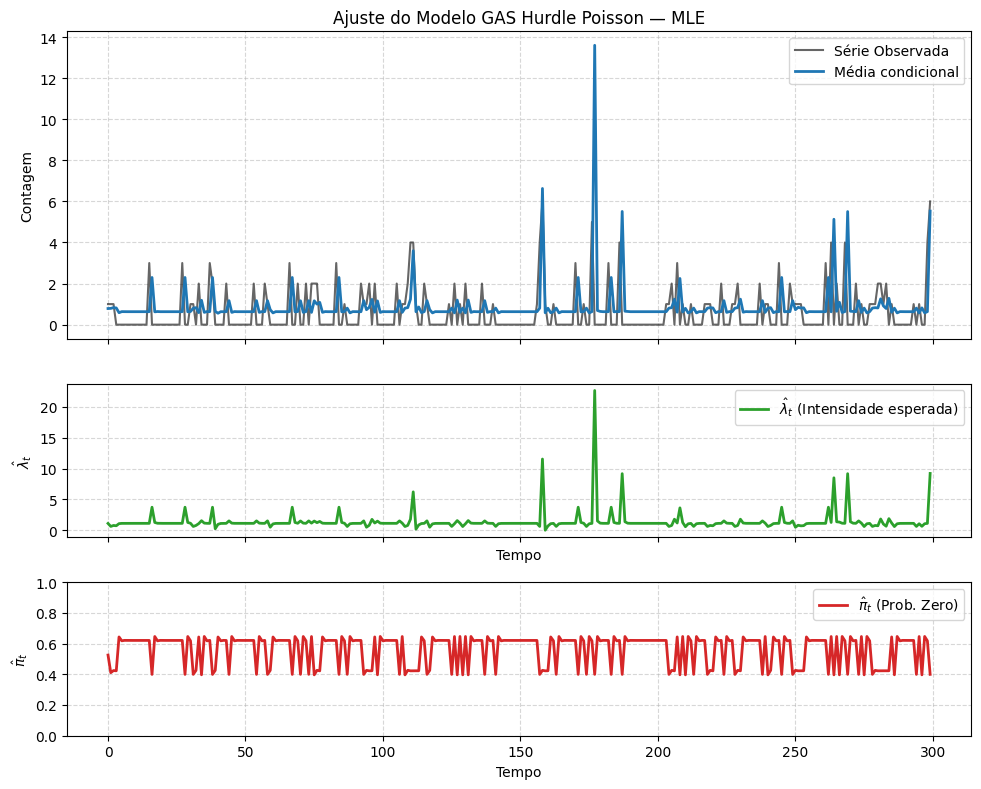

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2,1,1]})

# --- Gráfico superior: y_obs e lambda_hat ---
ax1.plot(y_obs, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(y_hat, label=r'Média condicional', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title("Ajuste do Modelo GAS Hurdle Poisson — MLE")

# --- Gráfico inferior: lambda_hat ---
ax2.plot(lambda_hat, label=r'$\hat{\lambda}_t$ (Intensidade esperada)', lw=2, color='tab:green')
ax2.set_xlabel("Tempo")
ax2.set_ylabel(r"$\hat{\lambda}_t$")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# --- Gráfico inferior: pi_hat ---
ax3.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax3.set_xlabel("Tempo")
ax3.set_ylabel(r"$\hat{\pi}_t$")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.6 Diagnóstico do GHP

In [18]:
def diagnostics_ghp(y, lambda_t, pi_t, title='Diagnóstico do Modelo GHP'):
    T = len(y)
    pit = np.zeros(T)
    quant_resid = np.zeros(T)
    pearson_resid = np.zeros(T)

    for t in range(T):
        y_t = y[t]
        lam = lambda_t[t]
        pi = pi_t[t]
        p0 = np.exp(-lam)
        p0 = np.clip(p0, 1e-12, 1 - 1e-12)

        if y_t == 0:
            # PIT uniforme em [0, pi_t]
            pit[t] = np.random.uniform(0, pi)
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança e variância condicional (y_t = 0)
            mu = (1 - pi) * lam / (1 - p0)
            var_trunc = lam * (1 + lam * p0 / (1 - p0))  # Var[Z|Z>0]
            var = (1 - pi) * (var_trunc + pi * (mu / (1 - pi))**2) - mu**2
            var = max(var, 1e-8)
            pearson_resid[t] = (0 - mu) / np.sqrt(var)

        else:
            # PIT com CDF da Poisson truncada
            def F_trunc(k):
                return (poisson.cdf(k, lam) - p0) / (1 - p0)

            F_lo = F_trunc(y_t - 1) if y_t > 1 else 0
            F_hi = F_trunc(y_t)
            u = np.random.uniform()
            pit[t] = pi + (1 - pi) * (F_lo + u * (F_hi - F_lo))
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança e variância condicional (y_t > 0)
            mu = (1 - pi) * lam / (1 - p0)
            var_trunc = lam * (1 + lam * p0 / (1 - p0))
            var = (1 - pi) * (var_trunc + pi * (mu / (1 - pi))**2) - mu**2
            var = max(var, 1e-3)
            pearson_resid[t] = (y_t - mu) / np.sqrt(var)

    # Gráficos
    fig, axs = plt.subplots(3, 2, figsize=(20, 10))
    fig.suptitle(f'{title} – PIT e Resíduos', fontsize=16)

    sns.histplot(pit, bins=20, kde=False, ax=axs[0, 0], color='skyblue')
    axs[0, 0].set_title('Histograma do PIT')
    axs[0, 0].axhline(T / 20, color='red', linestyle='--')

    sns.histplot(quant_resid, bins=30, kde=True, ax=axs[0, 1])
    axs[0, 1].set_title('Resíduos Quantílicos')

    probplot(quant_resid, dist="norm", plot=axs[1, 0])
    axs[1, 0].set_title('QQ-Plot do Resíduo Quantílico')

    axs[1, 1].scatter(range(T), pearson_resid, alpha=0.7)
    axs[1, 1].set_title('Resíduos de Pearson')
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)

    plot_acf(pearson_resid,lags=15, ax=axs[2, 0], title=f'FAC do resíduo de pearson')
    axs[2, 0].set_xticks(np.arange(15+1))
    axs[2, 0].set_xticklabels(np.arange(15+1))
    
    plot_acf(pearson_resid**2,lags=15, ax=axs[2, 1], title=f'FAC dos resíduos quadráticos')
    axs[2, 1].set_xticks(np.arange(15+1))
    axs[2, 1].set_xticklabels(np.arange(15+1))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pit, quant_resid, pearson_resid

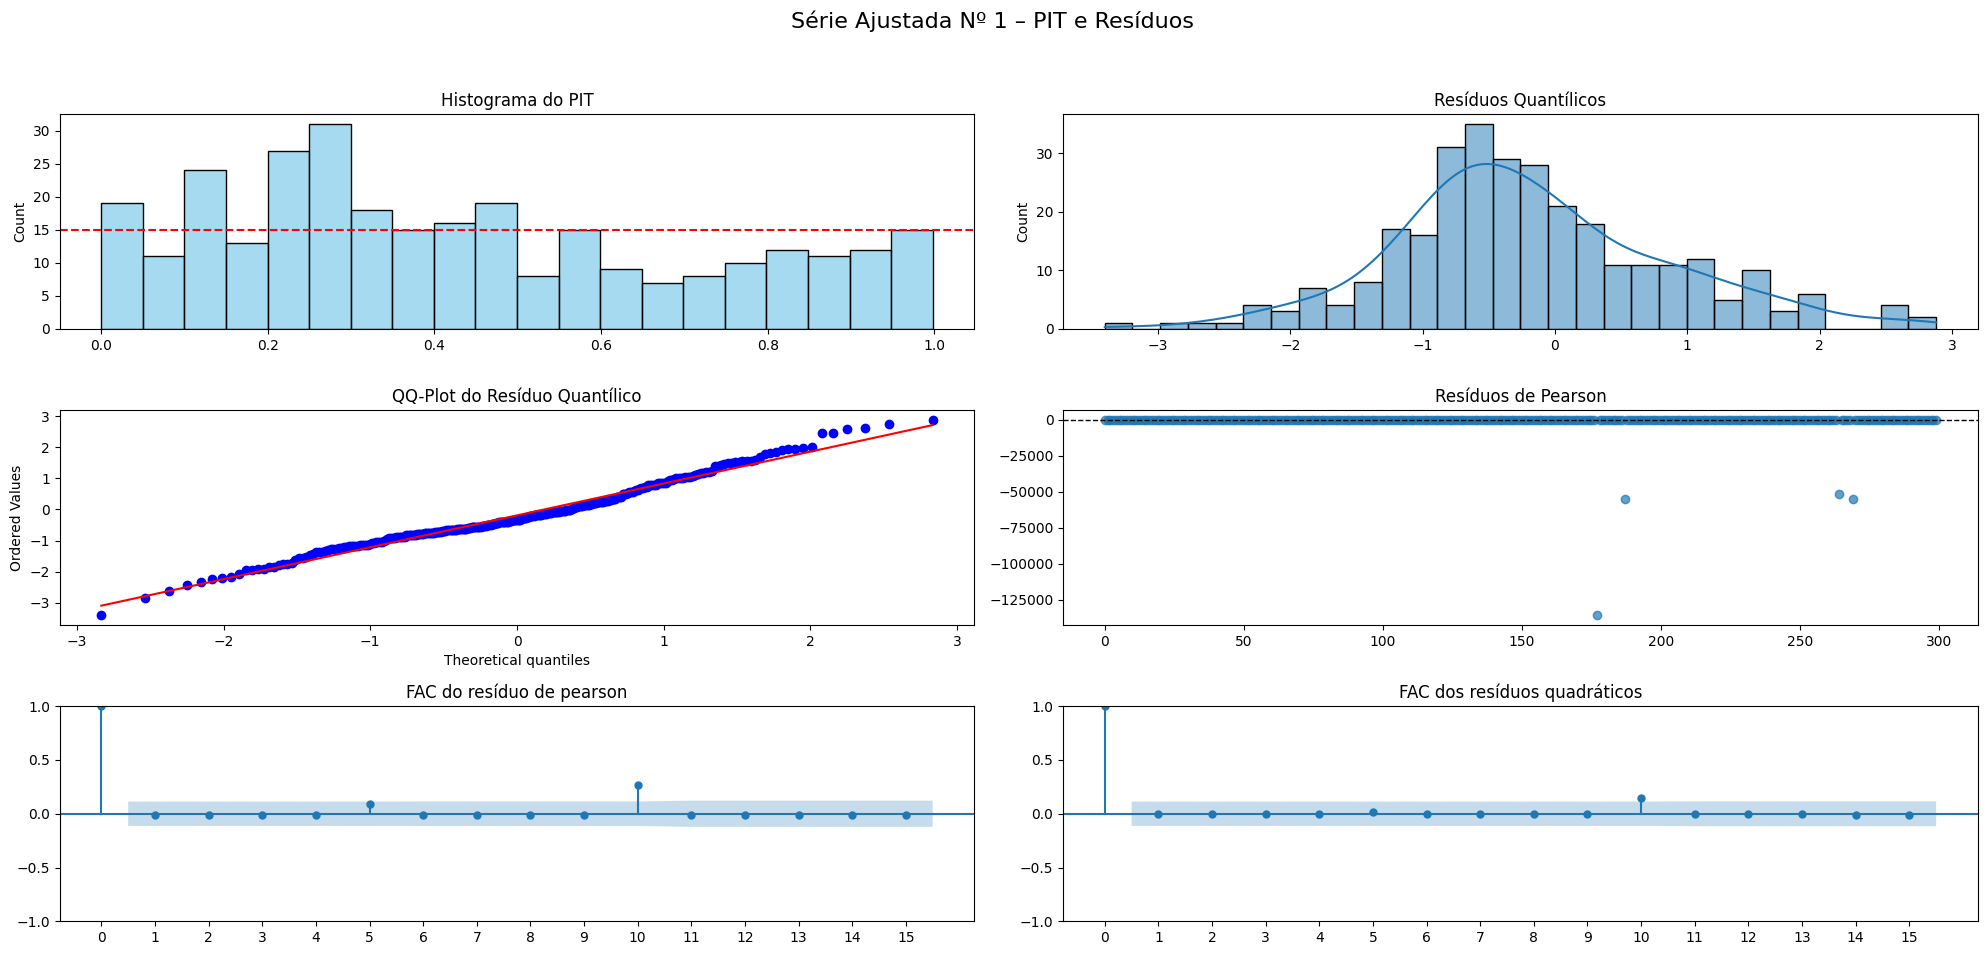

In [19]:
pit_vals, qresid, presid = diagnostics_ghp(
    y_obs, lambda_hat, pi_hat,
    title=f"Série Ajustada Nº {serie_indice+1}"
)

In [20]:
# Obter os índices dos 5 maiores valores absolutos
top5_idx = np.argsort(np.abs(presid))[-5:][::-1]  # ordena do maior pro menor

# Construir um DataFrame para visualização
df_top5 = pd.DataFrame({
    'Índice': top5_idx,
    'y_obs': y_obs[top5_idx],
    'lambda_hat': lambda_hat[top5_idx],
    'Pearson Residual': presid[top5_idx]
})

# Visualizar os resultados
df_top5.reset_index(drop=True, inplace=True)

df_top5

,Índice,y_obs,lambda_hat,Pearson Residual
0,177,0,22.645213,-136001.055225
1,187,0,9.168321,-55100.820921
2,269,0,9.165781,-55052.566493
3,264,0,8.496947,-51310.048398
4,158,6,11.540272,-19.910077


### 1.7 Previsão $k$ passos à frente

In [21]:
def forecast_ghp(k, y_obs, params, n_sim=1000, seed=None):
    """
    Previsão k-passos à frente para modelo GAS Hurdle Poisson com ICs por simulação.

    Parâmetros:
    - k: horizonte de previsão
    - y_obs: série observada
    - params: dicionário com parâmetros estimados
    - n_sim: número de trajetórias simuladas
    - seed: semente aleatória (reprodutibilidade)

    Retorna:
    - y_sim: array (n_sim, k) com trajetórias simuladas
    - y_mean: previsão média por passo
    - y_ci_low: percentil 2.5% (IC inferior)
    - y_ci_high: percentil 97.5% (IC superior)
    """
    if seed is not None:
        np.random.seed(seed)

    # Parâmetros
    delta_lambda = params['delta_lambda']
    beta_lambda = params['beta_lambda']
    rho_lambda = params['rho_lambda']
    delta_pi = params['delta_pi']
    beta_pi = params['beta_pi']
    rho_pi = params['rho_pi']

    # Inicialização dos filtros com último valor in-sample
    f_lambda = delta_lambda
    f_pi = delta_pi

    # Atualização f_lambda e f_pi com dados observados
    for y in y_obs:
        lam = np.clip(np.exp(f_lambda), 1e-6, 50)
        pi = np.clip(1 / (1 + np.exp(-f_pi)), 1e-6, 1 - 1e-6)
        p0 = np.exp(-lam)

        if y == 0:
            s_pi = 1 - pi
            s_lambda = 0.0
        else:
            trunc = lam * np.exp(-lam) / (1 - np.exp(-lam))
            s_pi = -pi
            s_lambda = y - lam - trunc

        f_lambda = delta_lambda + beta_lambda * f_lambda + rho_lambda * s_lambda
        f_pi = delta_pi + beta_pi * f_pi + rho_pi * s_pi

        # Segurança
        f_lambda = np.clip(f_lambda, -5, 4)
        f_pi = np.clip(f_pi, -6, 6)

    # Simulações futuras
    y_sim = np.zeros((n_sim, k))

    for s in range(n_sim):
        f_lam_sim = f_lambda
        f_pi_sim = f_pi

        for h in range(k):
            lam = np.clip(np.exp(f_lam_sim), 1e-6, 50)
            pi = np.clip(1 / (1 + np.exp(-f_pi_sim)), 1e-6, 1 - 1e-6)
            p0 = np.exp(-lam)

            u = np.random.rand()
            if u < pi:
                y_sim[s, h] = 0
                s_pi = 1 / pi
                s_lambda = 0.0
            else:
                while True:
                    z = np.random.poisson(lam)
                    if z > 0:
                        y_sim[s, h] = z
                        break
                s_pi = -pi
                trunc = lam * np.exp(-lam) / (1 - np.exp(-lam))
                s_lambda = y_sim[s, h] - lam - trunc

            # Atualização das equações GAS
            f_lam_sim = delta_lambda + beta_lambda * f_lam_sim + rho_lambda * s_lambda
            f_pi_sim = delta_pi + beta_pi * f_pi_sim + rho_pi * s_pi

            # Segurança
            f_lam_sim = np.clip(f_lam_sim, -5, 4)
            f_pi_sim = np.clip(f_pi_sim, -6, 6)

    # Estatísticas
    y_mean = np.mean(y_sim, axis=0)
    y_ci_low = np.percentile(y_sim, 2.5, axis=0)
    y_ci_high = np.percentile(y_sim, 97.5, axis=0)

    return y_sim, y_mean, y_ci_low, y_ci_high

In [22]:
k = 10

y_sim, y_mean, y_ci_low, y_ci_high = forecast_ghp(k, y_obs, theta_hat_dict, n_sim=1000, seed=42)

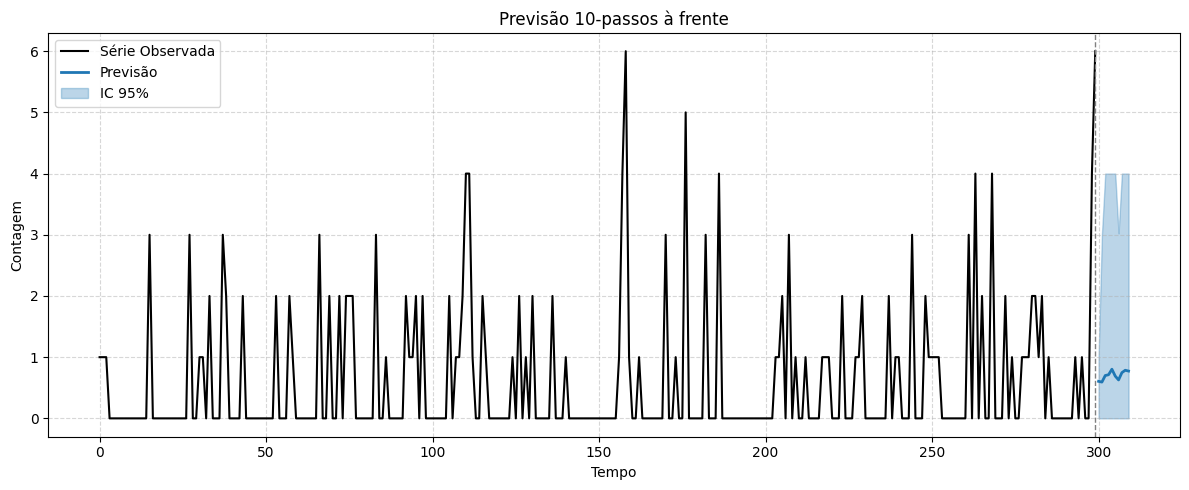

In [23]:
plot_forecast(y_obs, y_mean, np.array([y_ci_low, y_ci_high]))

## 2. GAS Hurdle Negative Binomial (GHNB)

O modelo hurdle binomial negativa (HNB) segue a mesma lógica do HP, porém a parte positiva é amostrada de uma **Binomial Negativa truncada em zero**.

A função de massa é:

$$
p(y_t \mid \mu_{t|t-1}, \alpha, \pi_{t|t-1}) =
\begin{cases}
\pi_{t|t-1}, & y_t = 0, \\[8pt]
(1 - \pi_{t|t-1})
\dfrac{
\Gamma(y_t + \alpha)
}{
\Gamma(y_t + 1)\Gamma(\alpha)
}
\left(
\frac{1}{1 + \frac{\mu_{t|t-1}}{\alpha}}
\right)^{\alpha}
\left(
1 - 
\frac{1}{
1 + \frac{\mu_{t|t-1}}{\alpha}
}
\right)^{y_t}
\dfrac{1}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
},
& y_t > 0.
\end{cases}
$$

com  
- $\mu_{t|t-1} > 0$,  
- $\alpha > 0$,  
- $\pi_{t|t-1} \in (0,1)$.

### 2.1 Média e Variância

$$
\mathbb{E}_{t-1}[y_t]
=
\frac{\mu_{t|t-1}(1 - \pi_{t|t-1})}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
$$

$$
\operatorname{Var}_{t-1}[y_t]
=
\pi_{t|t-1}(1 - \pi_{t|t-1})
\left(
\frac{\mu_{t|t-1}}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
}
\right)^2
+
(1 - \pi_{t|t-1})
\left[
\dfrac{
\mu_{t|t-1}\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)
}{
1 - \left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
-
\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}
\left(
\frac{\mu_{t|t-1}}{
1 -
\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right)^{-\alpha}}
\right)^2
\right]
$$

### 2.2 Dinâmica dos parâmetros

Faremos o passo a passo na derivação das dinâmicas do modelo GHNB, calcularemos tanto com a função _link_ identidade, como também reparametrizada conforme as funções _link_ abaixo

$$
h_1(\pi_{t|t-1}) = \tilde{\pi}_{t|t-1} = \ln\left( \frac{\pi_{t|t-1}}{1 - \pi_{t|t-1}} \right), \qquad
h_2(\mu_{t|t-1}) = \tilde{\mu}_{t|t-1} = \ln(\mu_{t|t-1})
$$

#### 2.2.1 Gradiente da função de probabilidade condicional

Como visto, a função de probabilidade condicional é uma mistura:

$$
\ln(p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) + \ln\Gamma(y_t + \alpha) - \ln\Gamma(y_t + 1) - \ln\Gamma(\alpha) \\\\
\quad - \alpha \ln\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right) + y_t \ln(\mu_{t|t-1}) - y_t \ln(\mu_{t|t-1} + \alpha), & \text{se } y_t > 0
\end{cases}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\nabla_{y_t = 0} =
\begin{bmatrix}
\nabla_{y_t=0}^{\pi_{t|t-1}} \\\\
\nabla_{y_t=0}^{\mu_{t|t-1}}
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}} \\\\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\nabla_{y_t > 0} =
\begin{bmatrix}
\nabla_{y_t>0}^{\pi_{t|t-1}} \\\\
\nabla_{y_t>0}^{\mu_{t|t-1}}
\end{bmatrix}
=
\begin{bmatrix}
- \frac{1}{1 - \pi_{t|t-1}} \\\\
\frac{y_t - \mu_{t|t-1}}{\mu_{t|t-1} \left (1 + \frac{\mu_{t|t-1}}{\alpha} \right )} - \frac{\left (1 + \frac{\mu_{t|t-1}}{\alpha} \right ) ^ {-(\alpha+1)}}{1 - \left ( 1 + \frac{\mu_{t|t-1}}{\alpha} \right ) ^ {- \alpha}}
\end{bmatrix}
$$

#### 2.2.2 Informação de Fisher

Para a informação de Fisher, temos que

$$
\mathcal{I}_{t|t-1} = \mathbb{E}_{t-1}
\left[
\begin{bmatrix}
(\nabla^{\pi_{t|t-1}})^2 & \nabla^{\pi_{t|t-1}} \nabla^{\mu_{t|t-1}} \\
\nabla^{\mu_{t|t-1}} \nabla^{\pi_{t|t-1}} & (\nabla^{\mu_{t|t-1}})^2
\end{bmatrix}
\right]
=
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \text{Var}(\nabla^{\mu_{t|t-1}})
\end{bmatrix}
$$

Onde:

$$
(\nabla^{\pi_{t|t-1}})^2 = \frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})}, \qquad
\nabla^{\pi_{t|t-1}} \nabla^{\mu_{t|t-1}} = 0
$$

e

$$
\text{Var}(\nabla^{\mu_{t|t-1}}) = (1 - \pi_{t|t-1}) \cdot 
\left[
\frac{(1 + \tfrac{\mu_{t|t-1}}{\alpha})^{2 \alpha + 1} - (1 + \tfrac{\mu_{t|t-1}}{\alpha})^{\alpha + 1} - \mu_{t|t-1} (1 + \tfrac{\mu_{t|t-1}}{\alpha})^{\alpha}}{\mu_{t|t-1} (1 + \tfrac{\mu_{t|t-1}}{\alpha})^{2 \alpha + 2} + \mu_{t|t-1} (1 + \tfrac{\mu_{t|t-1}}{\alpha})^{2} - 2\mu_{t|t-1} (1 + \tfrac{\mu_{t|t-1}}{\alpha})^{\alpha + 2}}
\right]
$$

#### 2.2.3 Jacobiana das funções _link_

Dadas as funções $h_1$ e $h_2$ definidas acima, temos que 

$$
\tilde{h}_{t|t-1} =
\begin{bmatrix}
\frac{\partial h_1}{\partial \pi_{t|t-1}} & 0 \\\\
0 & \frac{\partial h_2}{\partial \mu_{t|t-1}}
\end{bmatrix} = 
\begin{bmatrix}
\frac{1}{\pi_{t|t-1}(1 - \pi_{t|t-1})} & 0 \\\\
0 & \frac{1}{\mu_{t|t-1}}
\end{bmatrix}
$$

Com isso, a inversa de $\tilde{h}_{t|t-1}$ é dada por

$$
\tilde{h}_{t|t-1}^{-1} =
\begin{bmatrix}
\pi_{t|t-1}(1 - \pi_{t|t-1}) & 0 \\\\
0 & \mu_{t|t-1}
\end{bmatrix}
$$

#### 2.2.4 _Score_ do GHP

Encontramos $\nabla_{y_t = 0}$ e $\nabla_{y_t > 0}$, que foram calculadas com base na função _link_ identidade. Agora encontraremos $\tilde{\nabla}_{y_t = 0}$ e $\tilde{\nabla}_{y_t > 0}$. para que possamos encontrar o _score_ e finalmente chegarmos à dinâmica dos parâmetros.

- Para $y_t = 0$:

$$
\tilde{\nabla}_{y_t = 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t = 0} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\\\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{\nabla}_{y_t > 0} =
\tilde{h}_{t|t-1}^{-1} \nabla_{y_t > 0} =
\begin{bmatrix}
- \pi_{t|t-1} \\\\
\frac{y_t - \mu_{t|t-1}}{1 + \frac{\mu_{t|t-1}}{\alpha}} - \frac{ \mu_{t|t-1} \left ( 1 + \frac{\mu_{t|t-1}}{\alpha} \right )^{-(\alpha + 1)}}{1 - \left ( 1 + \frac{\mu_{t|t-1}}{\alpha} \right )^{-\alpha}}
\end{bmatrix}
$$

Abaixo, encontramos a Informação de Fischer reparametrizada:

$$
\tilde{\mathcal{I}}_{t|t-1} =
\tilde{h}_{t|t-1}^{-1} \mathcal{I}_{t|t-1} \tilde{h}_{t|t-1}^{-1}
$$

Substituindo as matrizes:

$$
\tilde{\mathcal{I}}_{t|t-1}
=
\begin{bmatrix}
h_{1}^{-1} & 0 \\
0 & h_{2}^{-1}
\end{bmatrix}
\begin{bmatrix}
(\nabla^{\pi})^2 & 0 \\
0 & (\nabla^{\mu})^2
\end{bmatrix}
\begin{bmatrix}
h_{1}^{-1} & 0 \\
0 & h_{2}^{-1}
\end{bmatrix}
$$

Como todas as matrizes são diagonais, cada termo pode ser multiplicado elemento a elemento:

$$
\tilde{\mathcal{I}}_{t|t-1} =
\begin{bmatrix}
h_{1}^{-2} (\nabla^{\pi})^2 & 0 \\
0 & h_{2}^{-2} (\nabla^{\mu})^2
\end{bmatrix}
$$

onde:

- $h_{\pi}^{-2} = [\pi_{t|t-1}(1-\pi_{t|t-1})]^2$
- $h_{\mu}^{-2} = (\mu_{t|t-1})^2$

Expandindo a Informação de Fischer para cada caso, podemos encontrar os _scores_, conforme equação geral abaixo

$$
\tilde{s}_{t|t-1}
=
\left( \tilde{\mathcal{I}}_{t|t-1} \right)^{-d} \tilde{\nabla}_{t|t-1}
$$

Com isso, temos que

- Para $y_t = 0$:

$$
\tilde{s}_{y_t = 0} =
\begin{bmatrix}
1 - \pi_{t|t-1} \\
0
\end{bmatrix}
$$

- Para $y_t > 0$:

$$
\tilde{s}_{y_t > 0} =
\begin{bmatrix}
- \pi_{t|t-1} \\
\displaystyle \frac{ y_t - \mu_{t|t-1} }{ 1 + \tfrac{\mu_{t|t-1}}{\alpha} }
- 
\frac{
\mu_{t|t-1} \left( 1 + \tfrac{\mu_{t|t-1}}{\alpha} \right)^{-(\alpha + 1)}
}{
1 - \left( 1 + \tfrac{\mu_{t|t-1}}{\alpha} \right)^{-\alpha}
}
\end{bmatrix}
$$

Com isso, utilizamos os scores reparametrizados acima para atualizar $\tilde{\pi}_{t|t-1}$ e $\tilde{\mu}_{t|t-1}$ via uma estrutura GAS(1,1).

##### 2.2.4.1 Probabilidade de zero — $\tilde{\pi}_{t|t-1}$

$$
\tilde{\pi}_{t+1|t}
=
\delta_\pi
+
\beta_\pi \cdot \tilde{\pi}_{t|t-1}
+
\rho_\pi \cdot \tilde{s}_{\pi,t|t-1}
$$

onde:

- $\delta_\pi$: constante
- $\beta_\pi$: persistência
- $\rho_\pi$: peso do score
- $\tilde{s}_{\pi,t|t-1}$: componente do score referente a $\pi$

##### 2.2.4.2 Intensidade — $\tilde{\mu}_{t|t-1}$

$$
\tilde{\mu}_{t+1|t}
=
\delta_\mu
+
\beta_\mu \cdot \tilde{\mu}_{t|t-1}
+
\rho_\mu \cdot \tilde{s}_{\mu,t|t-1}
$$

onde:

- $\tilde{s}_{\mu,t|t-1}$: componente do score referente a $\mu$

### 2.3 Simulação

Abaixo simularemos o GHNB.

In [58]:
def simulate_ghnb(n_obs, params, seed=None, mu_max=50, logmu_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    if seed is not None:
        np.random.seed(seed)

    delta_mu, beta_mu, rho_mu = params['delta_mu'], params['beta_mu'], params['rho_mu']
    delta_pi, beta_pi, rho_pi = params['delta_pi'], params['beta_pi'], params['rho_pi']
    alpha = params['alpha']
    f_mu = params['f_mu0']
    f_pi = params['f_pi0']

    y = np.zeros(n_obs, dtype=int)
    mu_seq = np.zeros(n_obs)
    pi_seq = np.zeros(n_obs)

    for t in range(n_obs):
        mu_t = np.clip(np.exp(f_mu), 1e-6, mu_max)
        pi_t = 1 / (1 + np.exp(-f_pi))
        mu_seq[t] = mu_t
        pi_seq[t] = pi_t

        u = np.random.rand()
        if u < pi_t:
            y[t] = 0
        else:
            while True:
                p_nb = alpha / (alpha + mu_t)
                z = np.random.negative_binomial(alpha, p_nb)
                if z > 0:
                    y[t] = z
                    break

        A = 1 + mu_t / alpha
        denom = 1 - A**(-alpha)
        numer = y[t] - mu_t * A**(-(alpha + 1))

        score_pi = 1 - pi_t if y[t] == 0 else -pi_t
        score_mu = 0.0 if y[t] == 0 else numer / denom

        f_mu = np.clip(delta_mu + beta_mu * f_mu + rho_mu * score_mu, *logmu_bounds)
        f_pi = np.clip(delta_pi + beta_pi * f_pi + rho_pi * score_pi, *logitpi_bounds)

    return y, mu_seq, pi_seq

In [25]:
rng = np.random.default_rng(42)

# Gerar parâmetros aleatórios para 5 séries
series_list = []
param_list = []

n_obs = 200

for i in range(5):
    params_i = {
        'delta_pi': rng.uniform(-1.0, 1.0),
        'beta_pi':  rng.uniform(0.6, 0.95),
        'rho_pi':   rng.uniform(0.05, 0.3),
        'delta_mu': rng.uniform(-0.2, 0.8),
        'beta_mu':  rng.uniform(0.6, 0.95),
        'rho_mu':   rng.uniform(0.05, 0.3),
        'f_pi0':    rng.uniform(-2, 2),
        'f_mu0':    rng.uniform(-1, 1),
        'alpha':    rng.uniform(2, 6)
    }

    y_i, mu_i, pi_i = simulate_ghnb(
        n_obs=n_obs,
        params=params_i,
        seed=123 + i
    )

    series_list.append((y_i, mu_i, pi_i))
    param_list.append(params_i)

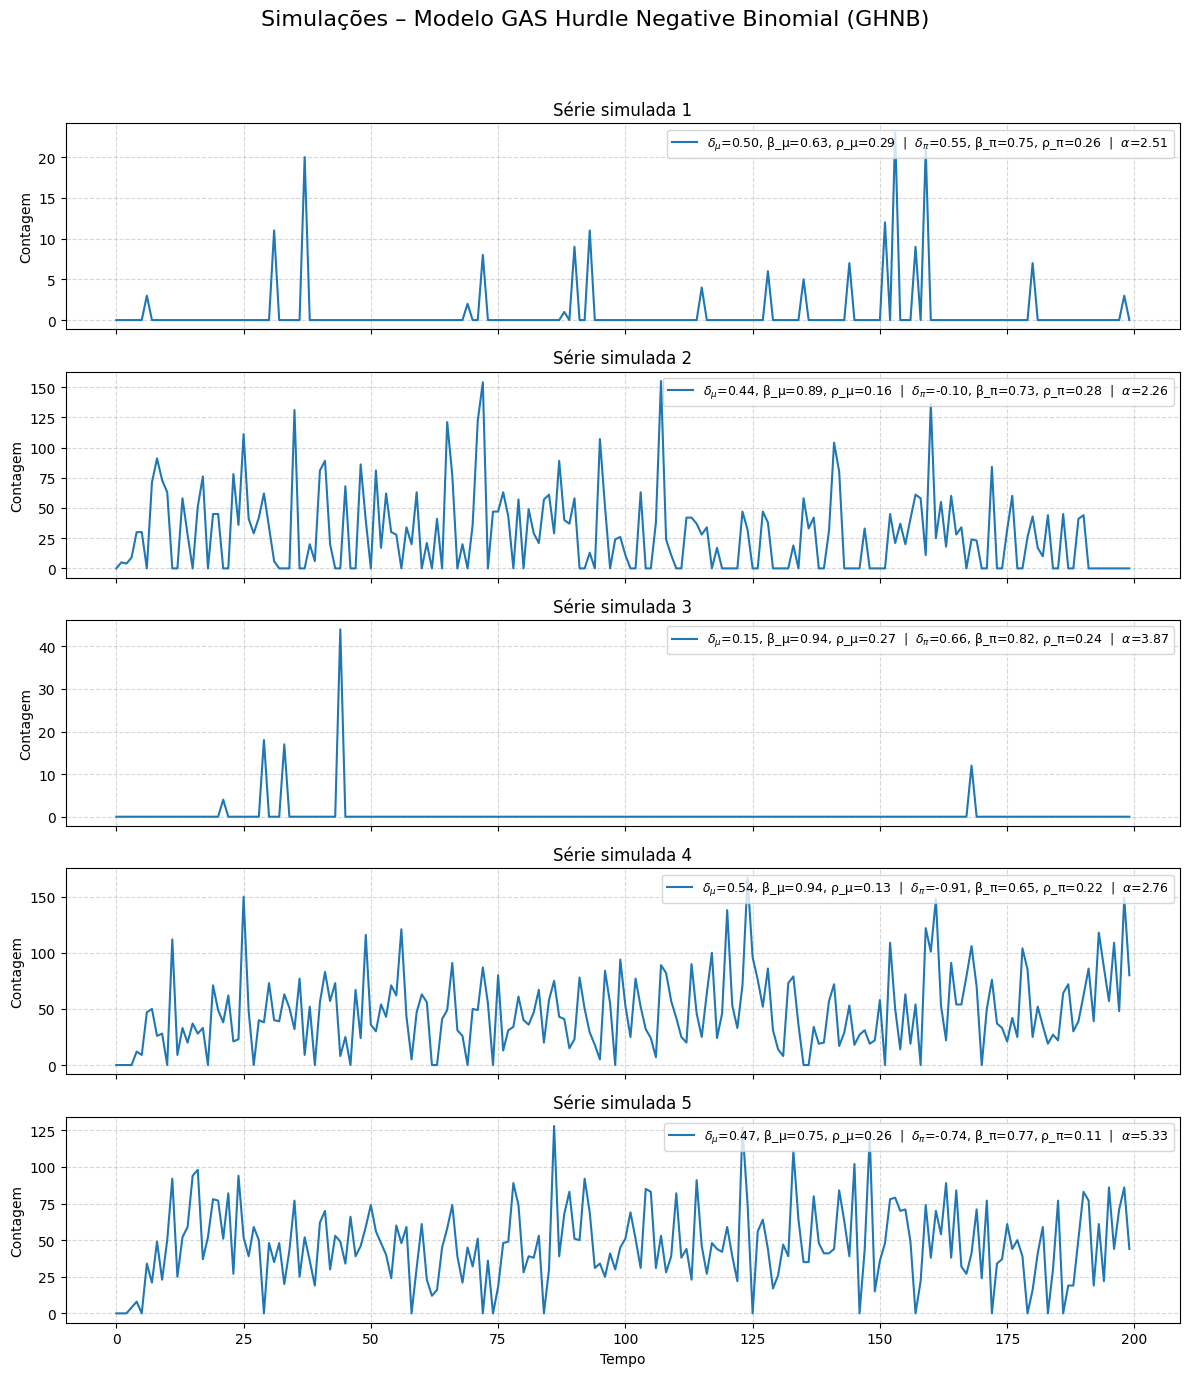

In [26]:
fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for i, (ax, (y, mu, pi), p) in enumerate(zip(axs, series_list, param_list)):

    legend_text = (
        f"$\\delta_\\mu$={p['delta_mu']:.2f}, β_μ={p['beta_mu']:.2f}, ρ_μ={p['rho_mu']:.2f}  |  "
        f"$\\delta_\\pi$={p['delta_pi']:.2f}, β_π={p['beta_pi']:.2f}, ρ_π={p['rho_pi']:.2f}  |  "
        f"$α$={p['alpha']:.2f}"
    )

    ax.plot(y, label=legend_text, lw=1.5)
    ax.set_ylabel("Contagem")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f"Série simulada {i+1}")

axs[-1].set_xlabel("Tempo")
fig.suptitle("Simulações – Modelo GAS Hurdle Negative Binomial (GHNB)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 2.4 Ajustando modelo GHP

Vimos que o log da probabilidade no modelo GHNB é dada por

$$
\ln(p(y_t \mid \lambda_{t|t-1}, \pi_{t|t-1})) =
\begin{cases}
\ln(\pi_{t|t-1}), & \text{se } y_t = 0 \\\\
\ln(1 - \pi_{t|t-1}) + \ln\Gamma(y_t + \alpha) - \ln\Gamma(y_t + 1) - \ln\Gamma(\alpha) \\\\
\quad - \alpha \ln\left(1 + \frac{\mu_{t|t-1}}{\alpha}\right) + y_t \ln(\mu_{t|t-1}) - y_t \ln(\mu_{t|t-1} + \alpha), & \text{se } y_t > 0
\end{cases}
$$

Com isso, a log-verossimilhança do modelo GHP é dada pelo seguinte somatório

$$
\ell(\theta)
=
\sum_{t=1}^T \ln p(y_t \mid \mathcal{F}_{t-1}, \theta)
$$

Além disso, os parâmetros $\pi_{t|t-1}$ e $\mu_{t|t-1}$, cuja dinâmica definimos anteriormente, tem a seguinte recorrência

$$
\tilde{\pi}_{t+1|t} = \delta_\pi + \beta_\pi \cdot \tilde{\pi}_{t|t-1} + \rho_\pi \cdot \tilde{s}_{\pi, t|t-1}
\quad \Rightarrow \quad
\pi_{t|t-1} = \text{expit}(\tilde{\pi}_{t|t-1})
$$

$$
\tilde{\mu}_{t+1|t} = \delta_\mu + \beta_\mu \cdot \tilde{\mu}_{t|t-1} + \rho_\mu \cdot \tilde{s}_{\mu, t|t-1}
\quad \Rightarrow \quad
\mu_{t|t-1} = \exp(\tilde{\mu}_{t|t-1})
$$

Com isso, o vetor de parâmetros estimado por MLE é:

$$
\Theta =
\left\{
\tilde{\mu}_{1|0}, \,
\tilde{\pi}_{1|0}, \,
\alpha, \,
\delta_\pi, \,
\beta_\pi, \,
\rho_\pi, \,
\delta_\mu, \,
\beta_\mu, \,
\rho_\mu
\right\}
\in
\mathbb{R}^6
$$

Com as restrições usuais:

- $\alpha > 0$

In [27]:
def ghnb_filter_paths(params, y, logmu_bounds=(-5, 4), logitpi_bounds=(-6, 6)):
    delta_mu, beta_mu, rho_mu = params['delta_mu'], params['beta_mu'], params['rho_mu']
    delta_pi, beta_pi, rho_pi = params['delta_pi'], params['beta_pi'], params['rho_pi']
    alpha = params['alpha']
    f_mu0, f_pi0 = params['f_mu0'], params['f_pi0']

    T = len(y)
    f_mu = np.zeros(T)
    f_pi = np.zeros(T)
    mu_t = np.zeros(T)
    pi_t = np.zeros(T)
    score_pi = np.zeros(T)
    score_mu = np.zeros(T)

    f_mu[0] = f_mu0
    f_pi[0] = f_pi0

    for t in range(T):
        mu_t[t] = np.exp(f_mu[t])
        pi_t[t] = 1 / (1 + np.exp(-f_pi[t]))

        if t < T - 1:
            A = 1 + mu_t[t] / alpha
            denom = 1 - A**(-alpha)
            numer = y[t] - mu_t[t] * A**(-(alpha + 1))

            score_pi[t] = 1 - pi_t[t] if y[t] == 0 else -pi_t[t]
            score_mu[t] = 0.0 if y[t] == 0 else numer / denom

            f_mu[t+1] = np.clip(delta_mu + beta_mu * f_mu[t] + rho_mu * score_mu[t], *logmu_bounds)
            f_pi[t+1] = np.clip(delta_pi + beta_pi * f_pi[t] + rho_pi * score_pi[t], *logitpi_bounds)

    return mu_t, pi_t, f_mu, f_pi, score_pi, score_mu

In [28]:
def neg_loglik_ghnb(params_array, y):
    delta_mu, beta_mu, rho_mu, delta_pi, beta_pi, rho_pi, log_alpha, f_mu0, f_pi0 = params_array
    alpha = np.exp(log_alpha)

    params = {
        'delta_mu': delta_mu, 'beta_mu': beta_mu, 'rho_mu': rho_mu,
        'delta_pi': delta_pi, 'beta_pi': beta_pi, 'rho_pi': rho_pi,
        'alpha': alpha, 'f_mu0': f_mu0, 'f_pi0': f_pi0
    }

    mu_t, pi_t, *_ = ghnb_filter_paths(params, y)

    loglik = 0.0
    for t in range(len(y)):
        mu = mu_t[t]
        pi = pi_t[t]
        A = 1 + mu / alpha
        r = alpha

        if y[t] == 0:
            loglik += np.log(pi)
        else:
            log_p_nb = (
                gammaln(y[t] + r) - gammaln(r) - gammaln(y[t] + 1)
                - r * np.log(A) + y[t] * np.log(mu) - y[t] * np.log(mu + r)
            )
            log_trunc = -np.log(1 - A**(-r))
            loglik += np.log(1 - pi) + log_p_nb + log_trunc

    return -loglik

In [29]:
indice_serie = 0
y_obs_nb = series_list[indice_serie][0]
parametros_originais = param_list[indice_serie]

init_params = [
    0.1,
    0.8,   # beta_mu        (persistência)
    0.3,   # rho_mu         (peso do score)
    0.1,
    0.8,   # beta_pi
    0.3,   # rho_pi
    np.log(3.0),   # log(alpha) — dispersão da NB
    0.1,   # tilde_mu_1|0   (estado inicial de log(mu))
    0.1,   # tilde_pi_1|0   (estado inicial de logit(pi))
]

result_nb = minimize(
    neg_loglik_ghnb,
    init_params,
    args=(y_obs_nb,),
    method="L-BFGS-B"
)

### 2.5 Resultados

#### 2.5.1 Comparando os parâmetros

Abaixo, mostramos os valores originais e estimados dos parametros.

In [30]:
theta_nb_hat = result_nb.x
print("\n==== Parâmetros Estimados (MLE) ====")
print(f"delta_mu={theta_nb_hat[0]:.4f}, beta_mu={theta_nb_hat[1]:.4f}, rho_mu={theta_nb_hat[2]:.4f}")
print(f"delta_pi={theta_nb_hat[3]:.4f}, beta_pi={theta_nb_hat[4]:.4f}, rho_pi={theta_nb_hat[5]:.4f}")
print(f"alpha={np.exp(theta_nb_hat[6]):.4f} (dispersão)")

print()
print("-" * 65)

print("\n==== Parâmetros Originais ====")
print(f"delta_mu={parametros_originais['delta_mu']:.4f}, beta_mu={parametros_originais['beta_mu']:.4f}, rho_mu={parametros_originais['rho_mu']:.4f}")
print(f"delta_pi={parametros_originais['delta_pi']:.4f}, beta_pi={parametros_originais['beta_pi']:.4f}, rho_pi={parametros_originais['rho_pi']:.4f}")
print(f"alpha={parametros_originais['alpha']:.4f} (dispersão)")


==== Parâmetros Estimados (MLE) ====
delta_mu=0.4725, beta_mu=0.7210, rho_mu=0.4833
delta_pi=3.9613, beta_pi=-0.4069, rho_pi=-7.5105
alpha=7.4692 (dispersão)

-----------------------------------------------------------------

==== Parâmetros Originais ====
delta_mu=0.4974, beta_mu=0.6330, rho_mu=0.2939
delta_pi=0.5479, beta_pi=0.7536, rho_pi=0.2646
alpha=2.5125 (dispersão)


#### 2.6.2 Mostrando os resultados

Seguem os gráficos para comparaçãos dos resultados.

In [31]:
params_dict = {
    "delta_mu": theta_nb_hat[0],
    "beta_mu": theta_nb_hat[1], 
    "rho_mu": theta_nb_hat[2],
    "delta_pi": theta_nb_hat[3],
    "beta_pi": theta_nb_hat[4],
    "rho_pi": theta_nb_hat[5],
    "alpha": np.exp(theta_nb_hat[6]),
    "f_mu0": theta_nb_hat[7],
    "f_pi0": theta_nb_hat[8],
}

# Estimar caminhos
mu_hat, pi_hat, _, _, score_pi, score_mu = ghnb_filter_paths(params_dict, y_obs)

# Probabilidade de zero da NB nao truncada
alpha_nb = params_dict["alpha"]
A = 1 + mu_hat / alpha_nb
p0 = np.clip(A ** (-alpha_nb), 1e-8, 1 - 1e-8)

# Esperança da NB truncada
mu_trunc = mu_hat / (1 - p0)

# Esperança da hurdle NB
yhat = (1 - pi_hat) * mu_trunc

In [32]:
def insample_forecast_ghnb(y, mu_t, pi_t, alpha_nb, 
                           title='In-sample: Observado vs E[y|t-1] – GHNB'):
    """
    Esperança condicional in-sample do modelo GAS Hurdle Negative Binomial (GHNB):

        E[y_t | t-1] = (1 - pi_t) * mu_t / (1 - (1 + mu_t/alpha)^(-alpha))

    Parâmetros:
    - y: série observada
    - mu_t: sequência filtrada de μ_t
    - pi_t: sequência filtrada de π_t
    - alpha_nb: dispersão α (>0)
    """

    # Probabilidade de zero da NB nao truncada
    A = 1 + mu_t / alpha_nb
    p0 = np.clip(A ** (-alpha_nb), 1e-12, 1 - 1e-12)

    # Esperança da NB truncada
    mu_trunc = mu_t / (1 - p0)

    # Esperança da hurdle NB
    yhat = (1 - pi_t) * mu_trunc

    # Métricas
    resid = y - yhat
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))

    metrics = {
        'rmse': float(rmse),
        'mae': float(mae)
    }

    # ============== GRÁFICO ==============
    fig, ax = plt.subplots(figsize=(12, 4.5))

    ax.plot(y, label='Observado (y)', linewidth=1, alpha=0.9)
    ax.plot(yhat, label=r'E$_{t-1}[y_t]$ (GHNB)', linewidth=1.8, alpha=0.9)

    ax.set_title(title)
    ax.set_xlabel("Tempo")
    ax.set_ylabel("Contagem")
    ax.legend()
    ax.grid(alpha=0.25)

    # Caixa com métricas
    textstr = (
        f"RMSE = {metrics['rmse']:.4f}\n"
        f"MAE  = {metrics['mae']:.4f}"
    )
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)

    ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

    return yhat, metrics

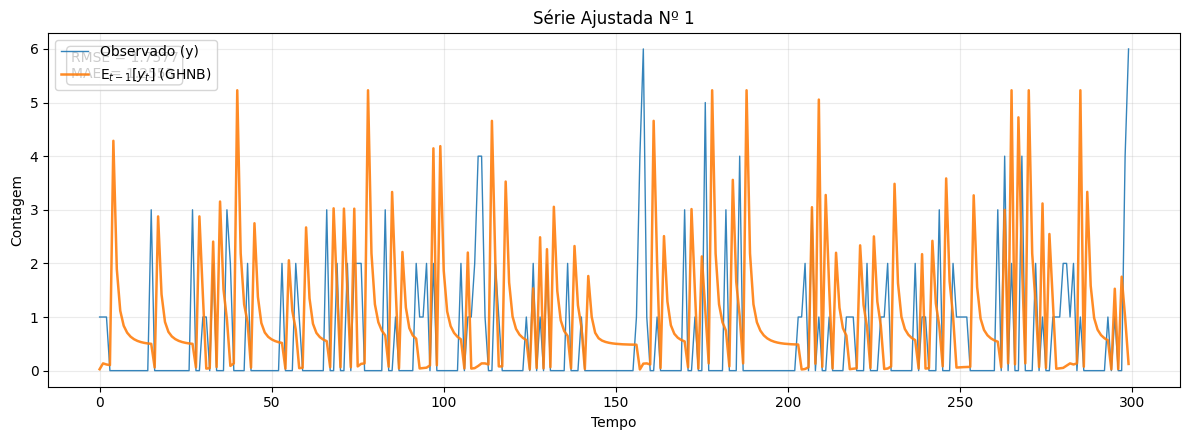

In [33]:
y_hat, metrics = insample_forecast_ghnb(
    y_obs, mu_hat, pi_hat, alpha_nb, 
    title=f"Série Ajustada Nº {serie_indice+1}"
)

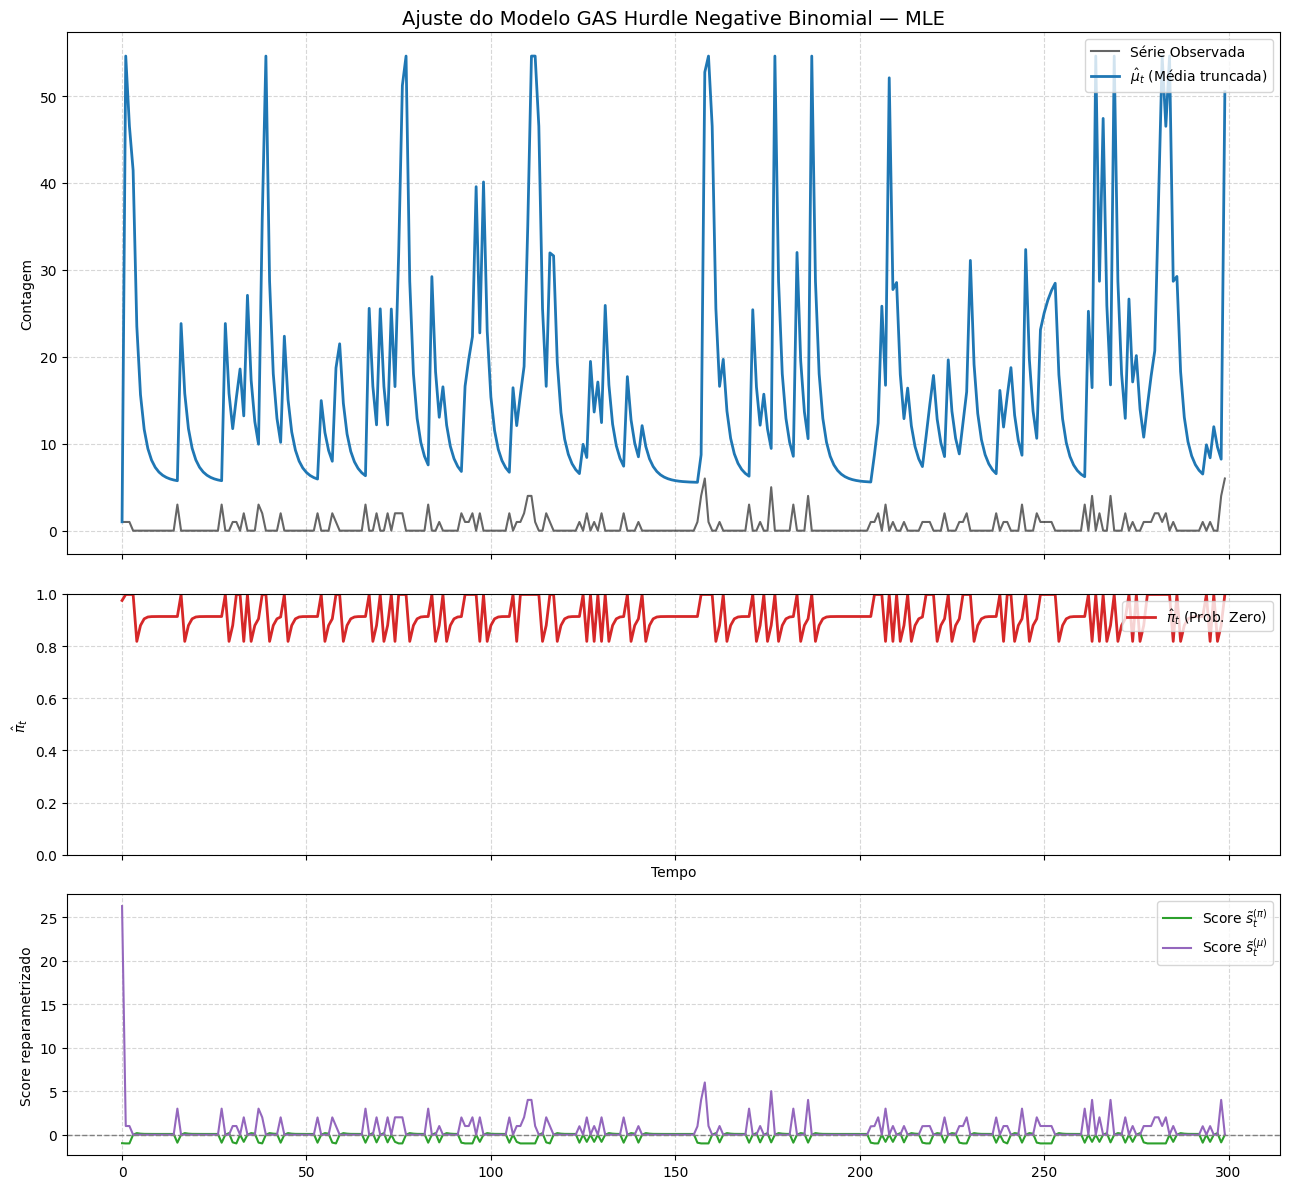

In [34]:
fig, axs = plt.subplots(3, 1, figsize=(13, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

# === GRÁFICO 1: Série observada + mu + pi ===
ax1 = axs[0]

# Eixo esquerdo
ax1.plot(y_obs, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(mu_trunc, label=r'$\hat{\mu}_t$ (Média truncada)', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')

# Título
ax1.set_title("Ajuste do Modelo GAS Hurdle Negative Binomial — MLE", fontsize=14)


# === GRÁFICO 2: Scores ===
ax2 = axs[2]
ax2.plot(score_pi, label=r'Score $\tilde{s}^{(\pi)}_t$', lw=1.5, color='tab:green')
ax2.plot(score_mu, label=r'Score $\tilde{s}^{(\mu)}_t$', lw=1.5, color='tab:purple')
ax2.axhline(0, ls='--', color='gray', lw=1)
ax2.set_ylabel("Score reparametrizado")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)


# === GRÁFICO 3: Probabilidade isolada de zero ===
ax3 = axs[1]
ax3.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax3.set_xlabel("Tempo")
ax3.set_ylabel(r"$\hat{\pi}_t$")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 2.6 Diagnóstico do GHNB

In [35]:
def diagnostics_ghnb(y, mu_t, pi_t, alpha_nb, title='Diagnóstico do Modelo GHNB'):
    """
    Diagnósticos para o modelo GAS Hurdle Negative Binomial (GHNB):
    - PIT
    - Resíduos quantílicos
    - Resíduos de Pearson

    Parâmetros:
    - y: série observada
    - mu_t: médias condicionais μ_t
    - pi_t: probabilidades de zero π_t
    - alpha_nb: parâmetro de dispersão (α)
    """

    from scipy.stats import nbinom

    T = len(y)
    pit = np.zeros(T)
    quant_resid = np.zeros(T)
    pearson_resid = np.zeros(T)

    for t in range(T):
        y_t = y[t]
        mu = mu_t[t]
        pi = pi_t[t]
        r = alpha_nb

        # Parâmetros NB equivalentes
        p = r / (r + mu)   # probabilidade de sucesso na parametrização nbinom
        A = (1 + mu / r)

        # Probabilidade de zero da NB (não truncada)
        p0_nb = A ** (-r)
        p0_nb = np.clip(p0_nb, 1e-12, 1 - 1e-12)

        # === CASO 1: y_t = 0 ===========================================
        if y_t == 0:
            # PIT uniforme em [0, π_t]
            pit[t] = np.random.uniform(0, pi)
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança do hurdle NB:
            # E[Y] = (1 - π) * E[ Z | Z>0 ]
            # E[Z | Z>0] = μ / (1 - p0_nb)
            Ez_trunc = mu / (1 - p0_nb)
            EY = (1 - pi) * Ez_trunc

            # Variância de Z truncado (NB):
            # Var(Z) = μ (1 + μ/r)
            var_Z = mu * (1 + mu / r)
            # Var(Z | Z>0)
            var_Z_trunc = (var_Z / (1 - p0_nb)) - (mu**2 * p0_nb / ((1 - p0_nb)**2))

            # Var(Y)
            VarY = (1 - pi) * var_Z_trunc + (pi * (1 - pi)) * Ez_trunc**2
            VarY = max(VarY, 1e-8)

            pearson_resid[t] = (0 - EY) / np.sqrt(VarY)

        # === CASO 2: y_t > 0 ===========================================
        else:
            # CDF da NB truncada em zero:
            def F_nb_trunc(k):
                return (nbinom.cdf(k, r, p) - p0_nb) / (1 - p0_nb)

            F_lo = F_nb_trunc(y_t - 1) if y_t > 1 else 0
            F_hi = F_nb_trunc(y_t)

            u = np.random.uniform()
            pit[t] = pi + (1 - pi) * (F_lo + u * (F_hi - F_lo))
            quant_resid[t] = norm.ppf(pit[t])

            # Esperança da hurdle NB
            Ez_trunc = mu / (1 - p0_nb)
            EY = (1 - pi) * Ez_trunc

            # Variância
            var_Z = mu * (1 + mu / r)
            var_Z_trunc = (var_Z / (1 - p0_nb)) - (mu**2 * p0_nb / ((1 - p0_nb)**2))

            VarY = (1 - pi) * var_Z_trunc + (pi * (1 - pi)) * Ez_trunc**2
            VarY = max(VarY, 1e-8)

            pearson_resid[t] = (y_t - EY) / np.sqrt(VarY)

    # ==========================================================
    #                     GRÁFICOS
    # ==========================================================

    fig, axs = plt.subplots(3, 2, figsize=(20, 10))
    fig.suptitle(f'{title} – PIT e Resíduos', fontsize=16)

    # PIT histogram
    sns.histplot(pit, bins=20, kde=False, ax=axs[0, 0], color='skyblue')
    axs[0, 0].set_title('Histograma do PIT')
    axs[0, 0].axhline(T / 20, color='red', linestyle='--')

    # Resíduos quantílicos
    sns.histplot(quant_resid, bins=30, kde=True, ax=axs[0, 1])
    axs[0, 1].set_title('Resíduos Quantílicos')

    # QQ-plot
    probplot(quant_resid, dist="norm", plot=axs[1, 0])
    axs[1, 0].set_title('QQ-Plot do Resíduo Quantílico')

    # Pearson
    axs[1, 1].scatter(range(T), pearson_resid, alpha=0.7)
    axs[1, 1].set_title('Resíduos de Pearson')
    axs[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)

    plot_acf(pearson_resid,lags=15, ax=axs[2, 0], title=f'FAC do resíduo de pearson')
    axs[2, 0].set_xticks(np.arange(15+1))
    axs[2, 0].set_xticklabels(np.arange(15+1))
    
    plot_acf(pearson_resid**2,lags=15, ax=axs[2, 1], title=f'FAC dos resíduos quadráticos')
    axs[2, 1].set_xticks(np.arange(15+1))
    axs[2, 1].set_xticklabels(np.arange(15+1))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pit, quant_resid, pearson_resid

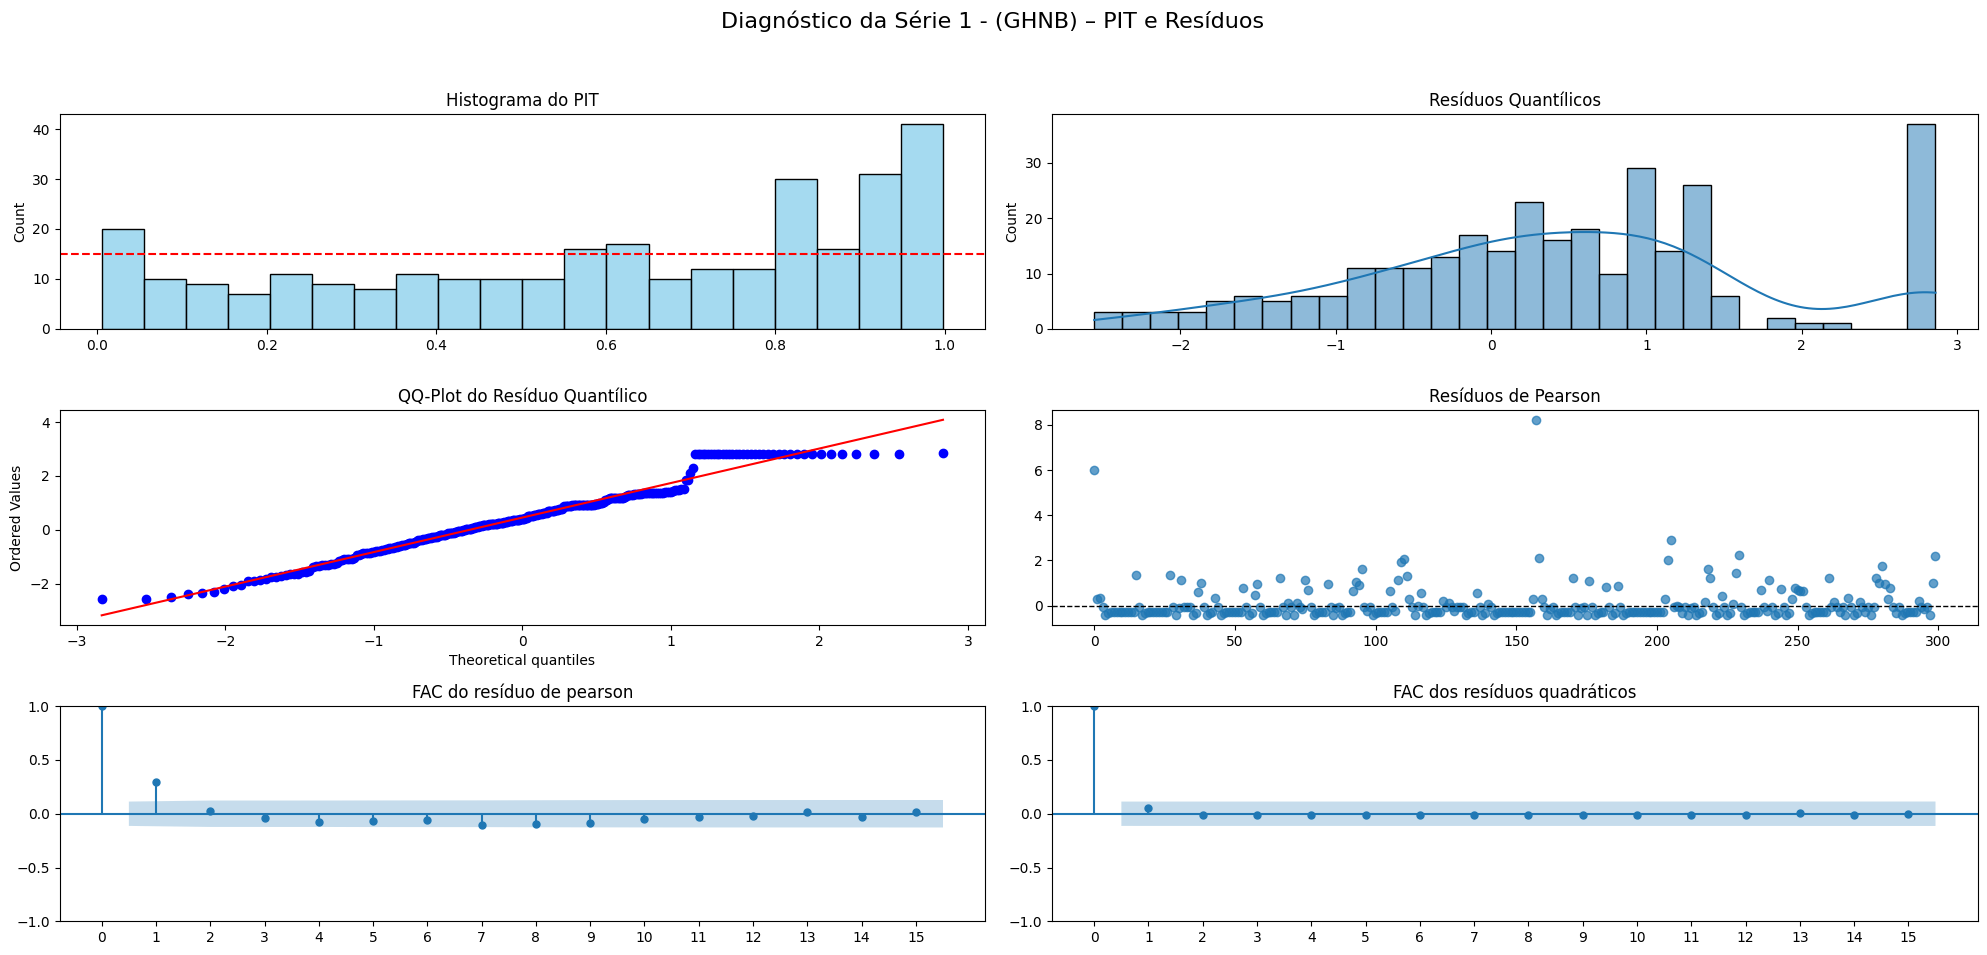

In [36]:
pit_ghnb, quant_resid_ghnb, pearson_resid_ghnb = diagnostics_ghnb(
    y=y_obs,
    mu_t=mu_hat,
    pi_t=pi_hat,
    alpha_nb=params_dict["alpha"],
    title=f"Diagnóstico da Série {indice_serie+1} - (GHNB)"
)

### 2.7 Previsao $k$ passos a frente

In [37]:
def forecast_ghnb(
    y_obs,              # série observada
    delta_pi, beta_pi, rho_pi,   # dinâmica de logit(π_t)
    delta_mu, beta_mu, rho_mu,   # dinâmica de log(μ_t)
    f_pi0, f_mu0,                # estados iniciais: logit(π_1|0), log(μ_1|0)
    alpha,                       # dispersão da NB
    k=10,                        # horizonte de previsão
    n_sim=5000,                  # número de simulações
    logmu_bounds=(-5, 4),
    logitpi_bounds=(-6, 6),
    seed=None
):
    """
    Previsão k-passos à frente para o modelo GAS Hurdle Negative Binomial (GHNB) via simulação.

    A dinâmica segue:
        - logit(π_{t+1|t}) = δ_pi + β_pi * logit(π_{t|t−1}) + ρ_pi * s_pi
        - log(μ_{t+1|t})   = δ_mu + β_mu * log(μ_{t|t−1})   + ρ_mu * s_mu

    Os scores reparametrizados usados são:
        - s_pi = 1 - π_t   se y_t = 0,  ou  -π_t se y_t > 0
        - s_mu conforme especificação da verossimilhança com truncamento

    Retorna:
        - y_sim: trajetórias simuladas (n_sim, k)
        - y_mean: previsão média
        - y_ci_low: percentil inferior (2.5%)
        - y_ci_high: percentil superior (97.5%)
    """

    if seed is not None:
        np.random.seed(seed)

    y_sim = np.zeros((n_sim, k))

    for s in range(n_sim):
        f_pi = f_pi0
        f_mu = f_mu0

        for h in range(k):
            # Inversas das funções link
            pi_t = expit(np.clip(f_pi, *logitpi_bounds))
            mu_t = np.clip(np.exp(f_mu), *logmu_bounds)

            # Simulação do y_t com hurdle
            u = np.random.rand()
            if u < pi_t:
                y_t = 0
            else:
                while True:
                    p_nb = alpha / (alpha + mu_t)
                    y_t = np.random.negative_binomial(alpha, p_nb)
                    if y_t > 0:
                        break

            y_sim[s, h] = y_t

            # Score reparametrizado
            if y_t == 0:
                s_pi = 1 - pi_t
                s_mu = 0.0
            else:
                A = 1 + mu_t / alpha
                numer = y_t - mu_t * A ** (-(alpha + 1))
                denom = 1 - A ** (-alpha)
                s_pi = -pi_t
                s_mu = numer / denom

            # Atualizações GAS
            f_pi = delta_pi + beta_pi * f_pi + rho_pi * s_pi
            f_mu = delta_mu + beta_mu * f_mu + rho_mu * s_mu

            # Clipping para estabilidade
            f_pi = np.clip(f_pi, *logitpi_bounds)
            f_mu = np.clip(f_mu, *logmu_bounds)

    # Estatísticas
    y_mean = np.mean(y_sim, axis=0)
    y_ci_low = np.percentile(y_sim, 2.5, axis=0)
    y_ci_high = np.percentile(y_sim, 97.5, axis=0)

    return y_sim, y_mean, y_ci_low, y_ci_high

In [38]:
y_sim, y_mean, y_lo, y_hi = forecast_ghnb(
    y_obs=y_obs, 
    **params_dict,
    k=10,
    n_sim=5000,
    seed=123
)

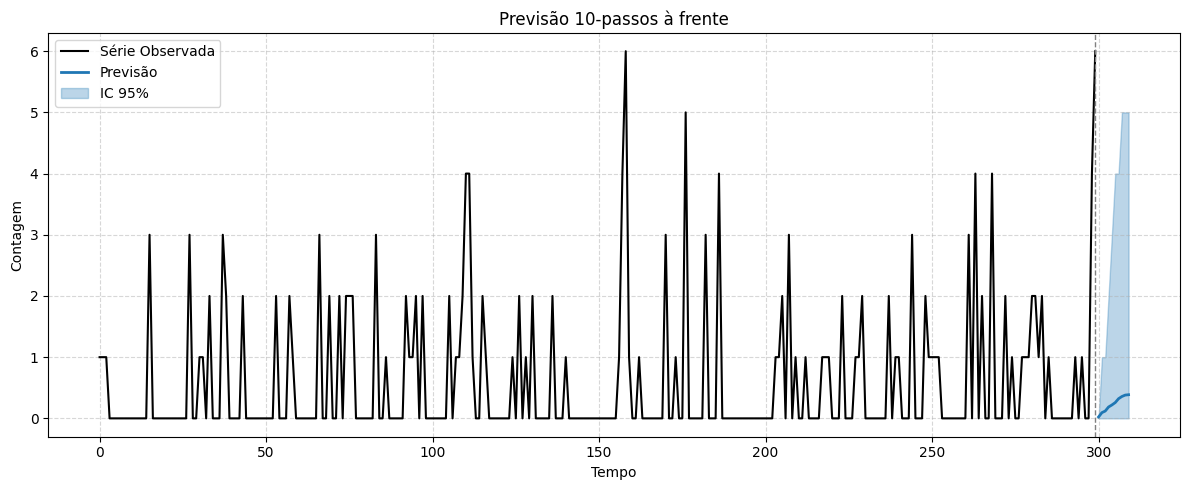

In [39]:
plot_forecast(y_obs, y_mean, np.array([y_lo, y_hi]))

## 3 Série real

Usaremos a base de quantidade de ocorrência de homicídios.

In [40]:
# Caminho base (arquivo atual)
pasta_atual = Path().resolve()

# Caminho relativo para a planilha
dados_seguranca_caminho = pasta_atual.parent.parent / "raw_databases" / "dados_seguranca.csv"

database = pd.read_csv(dados_seguranca_caminho)

In [41]:
database['date'] = database.apply(lambda row: dt.datetime(row['ano'], row['mes'], 1), axis=1)

database = database.set_index('date')

locations = database[['id_cisp','unidade_territorial']].set_index('id_cisp')['unidade_territorial'].to_dict()

In [42]:
var = 'quantidade_tentativa_homicidio'

data = database.loc[database.id_cisp==10, [var]]

# metadados
pd.DataFrame(index=['Metadados'], data={
    'Fonte':'Banco de Dados do Instituo de Segurança Pública do Rio de Janeiro (ISP)', 
    'Unidade':'Quantidade de ocorrências',
    'Período da série': '{} a {}'.format(database.index[0].strftime('%d/%m/%Y'), database.index[-1].strftime('%d/%m/%Y'))
}).T

,Metadados
Fonte,Banco de Dados do Instituo de Segurança Públic...
Unidade,Quantidade de ocorrências
Período da série,01/01/2003 a 01/10/2025


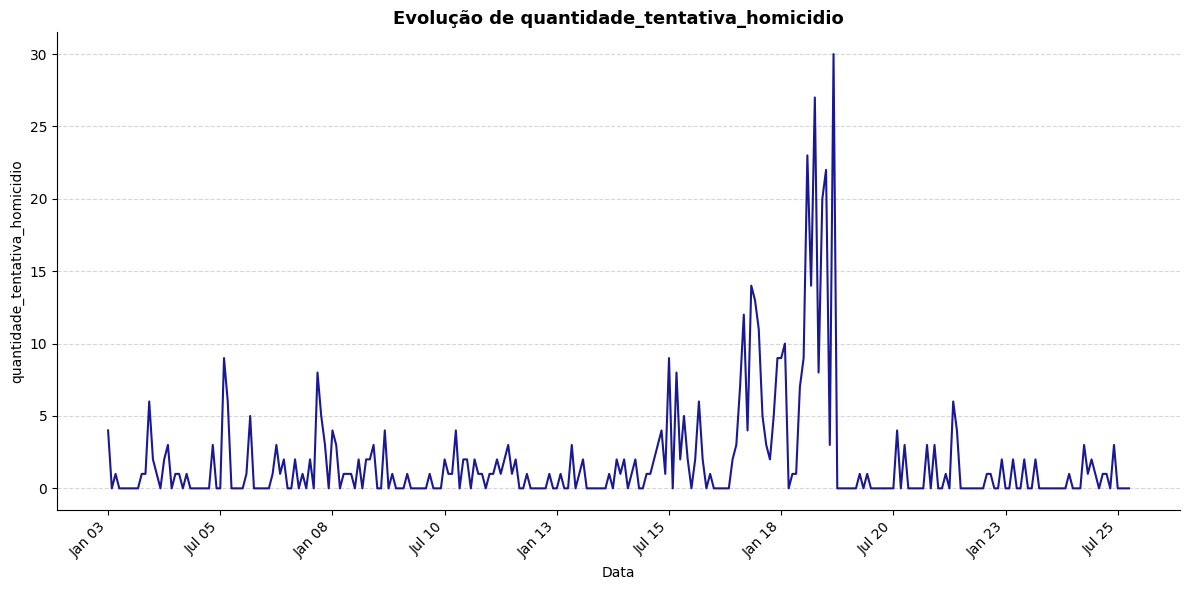

In [43]:
# Inicializa figura e eixo único
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de barras
ax.plot(np.arange(data.shape[0]), data[var], color="darkblue", alpha=0.9)

# Ticks de data no eixo X
tick_freq = 30
ticks = np.arange(0, data.shape[0], tick_freq)
ax.set_xticks(ticks)
ax.set_xticklabels(data.index[ticks].strftime("%b %y"), rotation=45, ha="right")

# Títulos e rótulos
ax.set_title(f"Evolução de {var}", fontsize=13, weight="bold")
ax.set_xlabel("Data")
ax.set_ylabel(var)

# Grade discreta no eixo Y
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)

# Fundo branco
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Remove borda superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 3.1 Ajustando ao GHP

In [44]:
y_obs_serie_real = data.values.reshape(-1)
n = len(y_obs_serie_real)

# Chute inicial sensato
x0 = np.array([0.1,0.1,0.1, 0.1, 0.9, 0.1, 0.1, 0.9])

bounds = [
    (-2, 2),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1),
    (-2, 2),
    (-2, 2),
    (-0.95, 0.95),
    (0, 1)
]

result_p = minimize(
    neg_loglik_ghp,
    x0,
    args=(y_obs_serie_real,),
    method="L-BFGS-B",
    bounds=bounds
)

C:\Users\aless\Desktop\Codes\venv\Lib\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [45]:
theta_p_hat = result_p.x

theta_p_hat_dict = {
    'lambda_tilde': theta_p_hat[0],
    'pi_tilde': theta_p_hat[1],
    'delta_lambda': theta_p_hat[2],
    'beta_lambda': theta_p_hat[3],
    'rho_lambda': theta_p_hat[4],
    'delta_pi': theta_p_hat[5],
    'beta_pi': theta_p_hat[6],
    'rho_pi':  theta_p_hat[7],
}

lambda_hat, pi_hat, f_lambda_hat, f_pi_hat, score_lambda, score_pi = filter_ghp(theta_p_hat_dict, y_obs_serie_real)

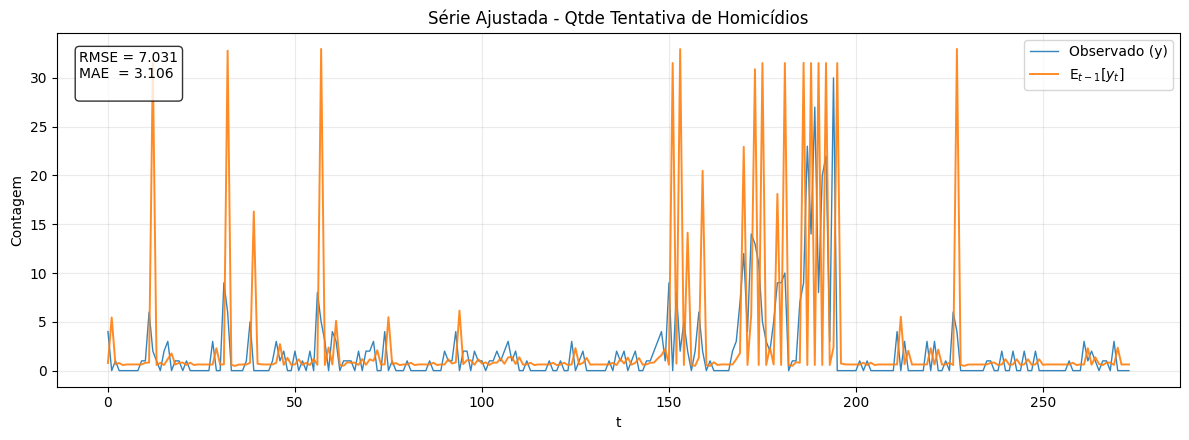

In [46]:
y_hat, metrics = insample_forecast_ghp(
    y_obs_serie_real, lambda_hat, pi_hat,
    title="Série Ajustada - Qtde Tentativa de Homicídios"
)

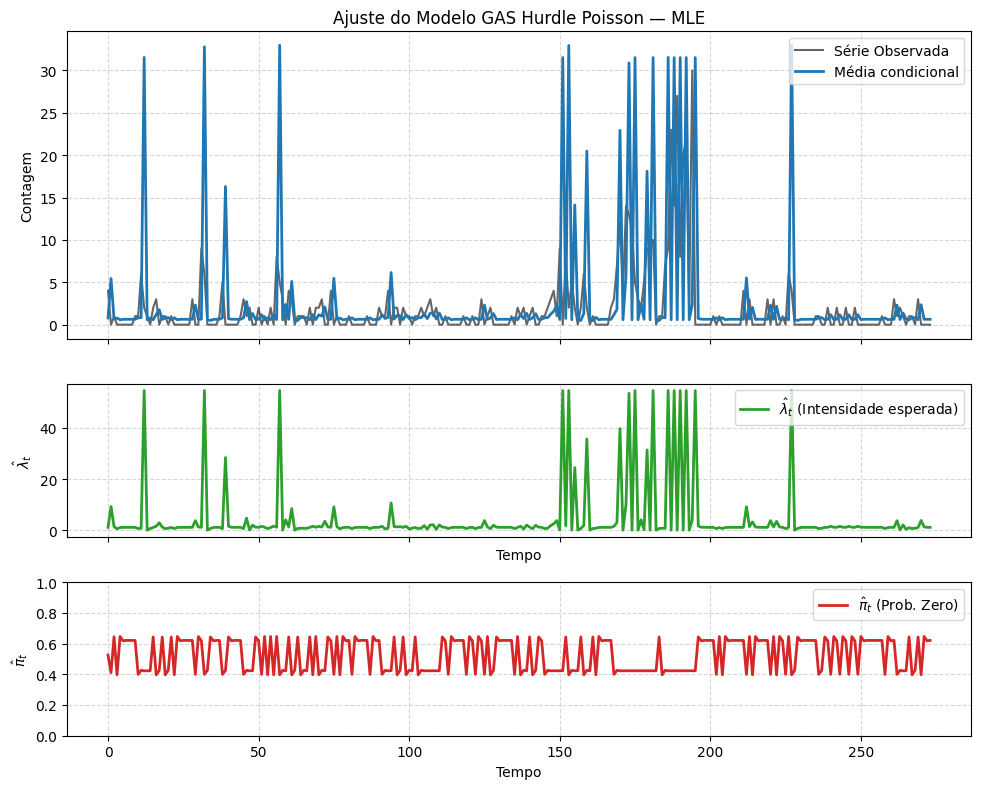

In [47]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2,1,1]})

# --- Gráfico superior: y_obs e lambda_hat ---
ax1.plot(y_obs_serie_real, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(y_hat, label=r'Média condicional', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title("Ajuste do Modelo GAS Hurdle Poisson — MLE")

# --- Gráfico inferior: lambda_hat ---
ax2.plot(lambda_hat, label=r'$\hat{\lambda}_t$ (Intensidade esperada)', lw=2, color='tab:green')
ax2.set_xlabel("Tempo")
ax2.set_ylabel(r"$\hat{\lambda}_t$")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# --- Gráfico inferior: pi_hat ---
ax3.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax3.set_xlabel("Tempo")
ax3.set_ylabel(r"$\hat{\pi}_t$")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\aless\Desktop\Codes\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


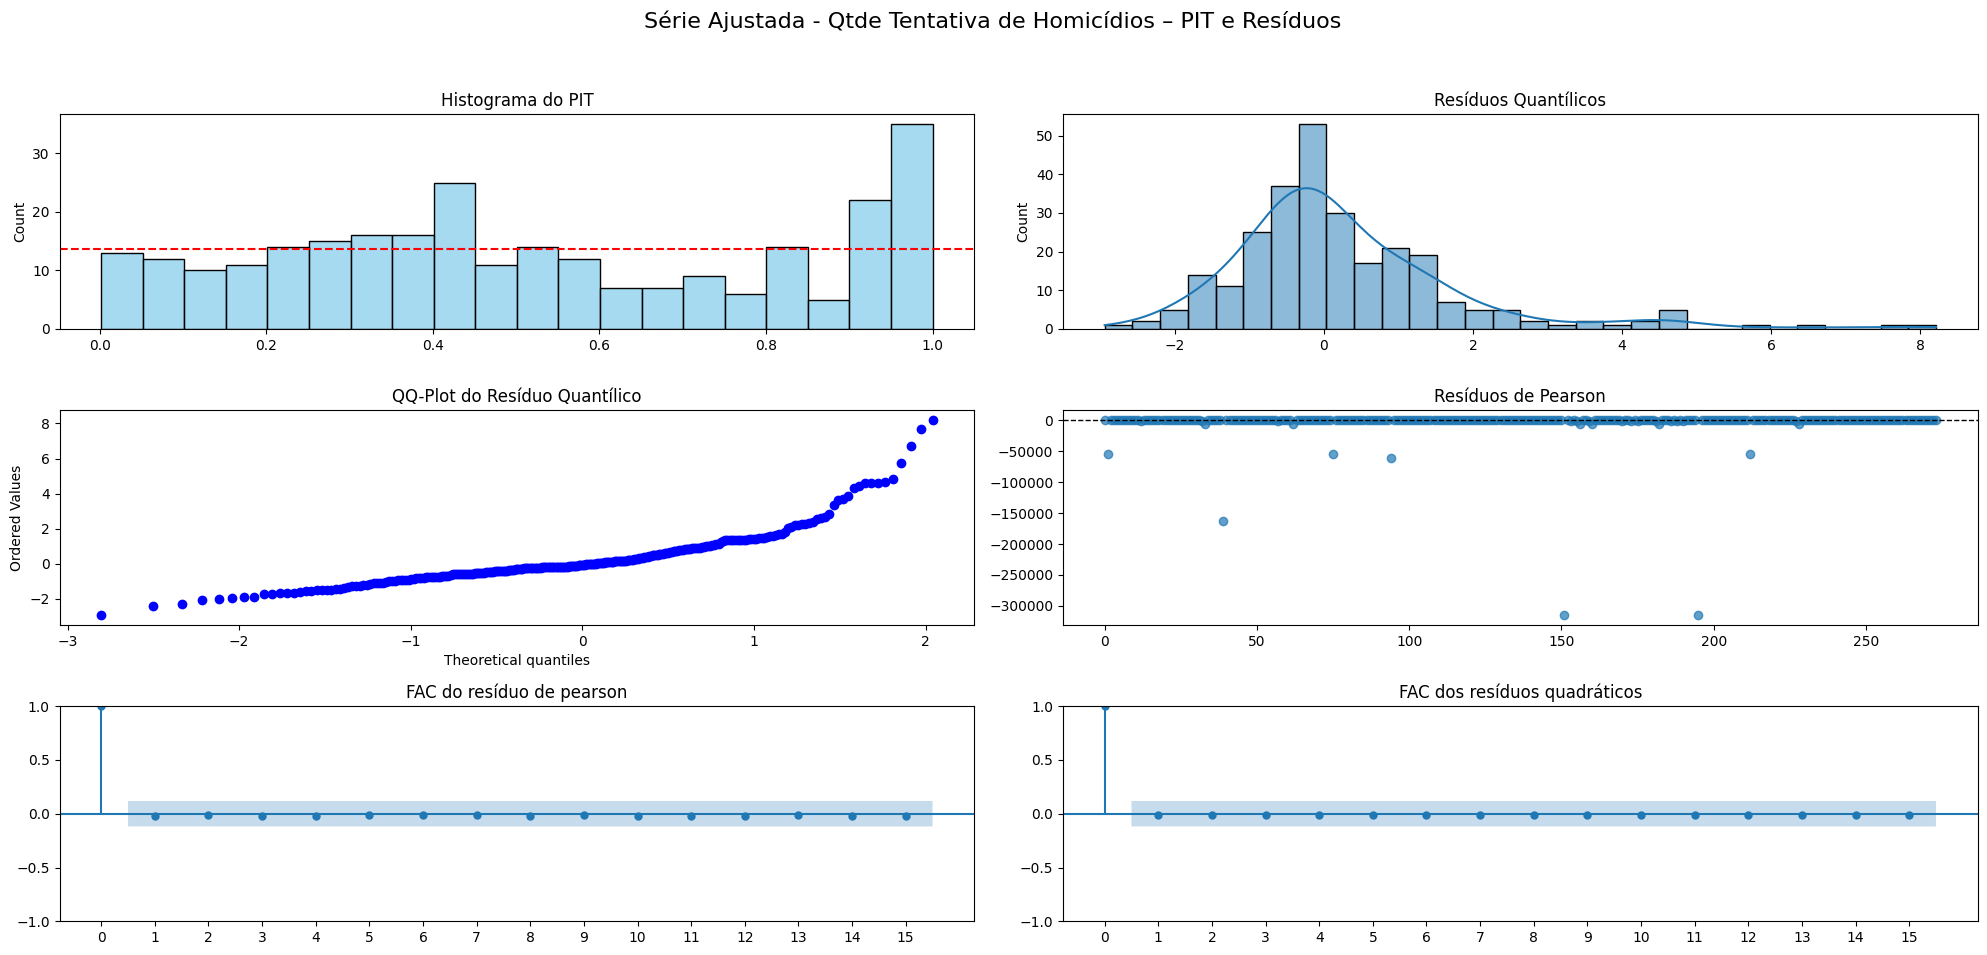

In [48]:
pit_vals, qresid, presid = diagnostics_ghp(
    y_obs_serie_real, lambda_hat, pi_hat,
    title="Série Ajustada - Qtde Tentativa de Homicídios"
)

In [49]:
# Obter os índices dos 5 maiores valores absolutos
top5_idx = np.argsort(np.abs(presid))[-5:][::-1]  # ordena do maior pro menor

# Construir um DataFrame para visualização
df_top5 = pd.DataFrame({
    'Índice': top5_idx,
    'y_obs': y_obs_serie_real[top5_idx],
    'lambda_hat': lambda_hat[top5_idx],
    'Pearson Residual': presid[top5_idx]
})

# Visualizar os resultados
df_top5.reset_index(drop=True, inplace=True)

df_top5

,Índice,y_obs,lambda_hat,Pearson Residual
0,151,0,54.598150,-315183.326520
1,195,0,54.598150,-315183.289393
2,39,0,28.382512,-163049.320653
3,94,0,10.651993,-61488.812102
4,212,0,9.174769,-55136.247916


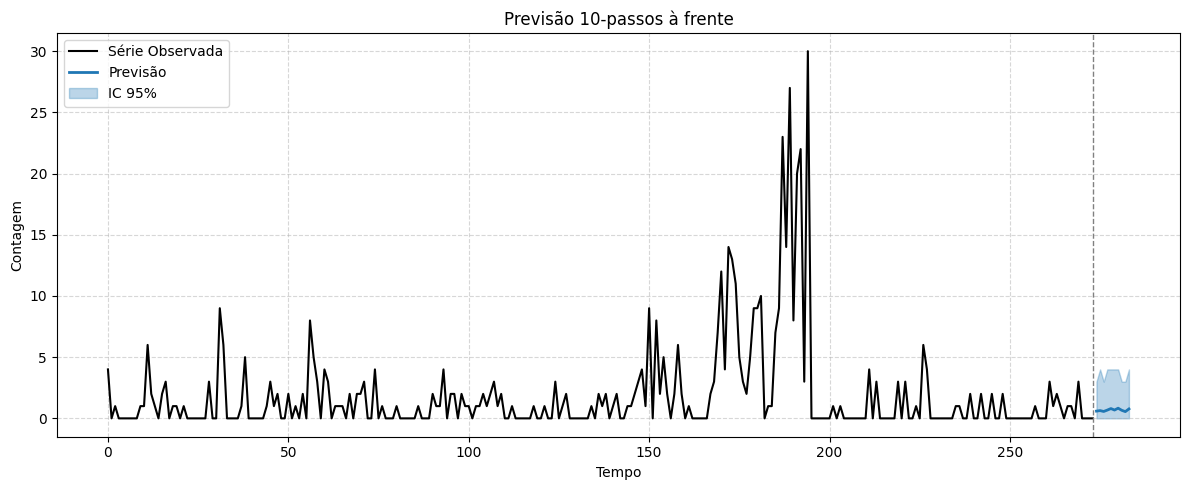

In [50]:
k = 10

y_sim, y_mean, y_ci_low, y_ci_high = forecast_ghp(k, y_obs_serie_real, theta_hat_dict, n_sim=1000, seed=42)

plot_forecast(y_obs_serie_real, y_mean, np.array([y_ci_low, y_ci_high]))

### 3.2 Ajustando ao GHNB

In [51]:
init_params = [
    0.1,
    0.8,   # beta_mu        (persistência)
    0.3,   # rho_mu         (peso do score)
    0.1,
    0.8,   # beta_pi
    0.3,   # rho_pi
    np.log(3.0),   # log(alpha) — dispersão da NB
    0.1,   # tilde_mu_1|0   (estado inicial de log(mu))
    0.1,   # tilde_pi_1|0   (estado inicial de logit(pi))
]

result_nb = minimize(
    neg_loglik_ghnb,
    init_params,
    args=(y_obs_serie_real,),
    method="L-BFGS-B"
)

In [52]:
theta_nb_hat = result_nb.x

params_dict = {
    "delta_mu": theta_nb_hat[0],
    "beta_mu": theta_nb_hat[1], 
    "rho_mu": theta_nb_hat[2],
    "delta_pi": theta_nb_hat[3],
    "beta_pi": theta_nb_hat[4],
    "rho_pi": theta_nb_hat[5],
    "alpha": np.exp(theta_nb_hat[6]),
    "f_mu0": theta_nb_hat[7],
    "f_pi0": theta_nb_hat[8],
}

# Estimar caminhos
mu_hat, pi_hat, _, _, score_pi, score_mu = ghnb_filter_paths(params_dict, y_obs_serie_real)

# Probabilidade de zero da NB nao truncada
alpha_nb = params_dict["alpha"]
A = 1 + mu_hat / alpha_nb
p0 = np.clip(A ** (-alpha_nb), 1e-8, 1 - 1e-8)

# Esperança da NB truncada
mu_trunc = mu_hat / (1 - p0)

# Esperança da hurdle NB
yhat = (1 - pi_hat) * mu_trunc

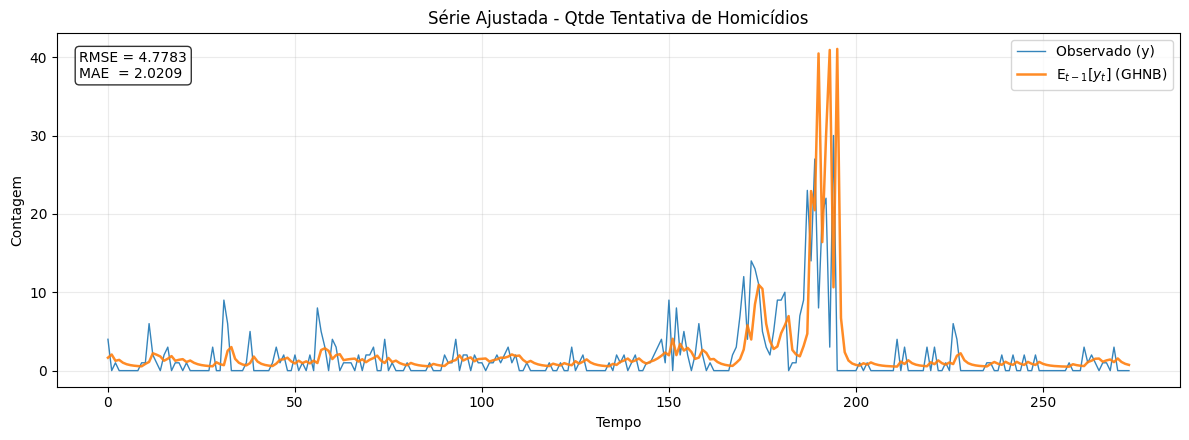

In [53]:
y_hat, metrics = insample_forecast_ghnb(
    y_obs_serie_real, mu_hat, pi_hat, alpha_nb, 
    title="Série Ajustada - Qtde Tentativa de Homicídios"
)

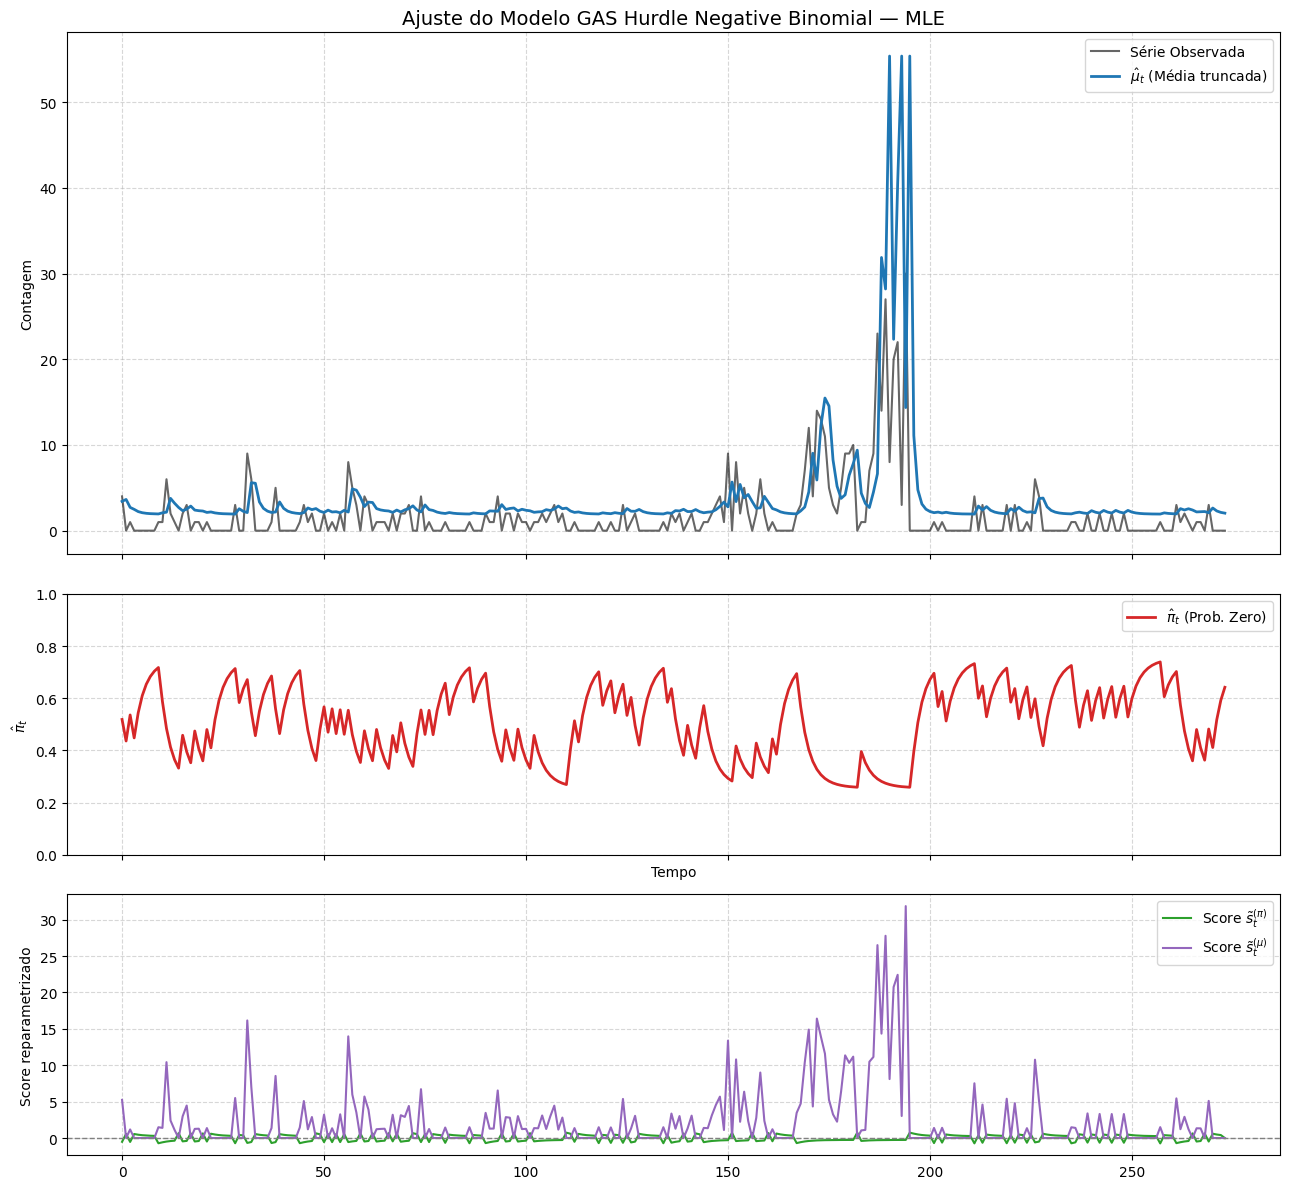

In [54]:
fig, axs = plt.subplots(3, 1, figsize=(13, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

# === GRÁFICO 1: Série observada + mu + pi ===
ax1 = axs[0]

# Eixo esquerdo
ax1.plot(y_obs_serie_real, label='Série Observada', lw=1.5, color='black', alpha=0.6)
ax1.plot(mu_trunc, label=r'$\hat{\mu}_t$ (Média truncada)', lw=2, color='tab:blue')
ax1.set_ylabel("Contagem", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')

# Título
ax1.set_title("Ajuste do Modelo GAS Hurdle Negative Binomial — MLE", fontsize=14)


# === GRÁFICO 2: Scores ===
ax2 = axs[2]
ax2.plot(score_pi, label=r'Score $\tilde{s}^{(\pi)}_t$', lw=1.5, color='tab:green')
ax2.plot(score_mu, label=r'Score $\tilde{s}^{(\mu)}_t$', lw=1.5, color='tab:purple')
ax2.axhline(0, ls='--', color='gray', lw=1)
ax2.set_ylabel("Score reparametrizado")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)


# === GRÁFICO 3: Probabilidade isolada de zero ===
ax3 = axs[1]
ax3.plot(pi_hat, label=r'$\hat{\pi}_t$ (Prob. Zero)', lw=2, color='tab:red')
ax3.set_xlabel("Tempo")
ax3.set_ylabel(r"$\hat{\pi}_t$")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

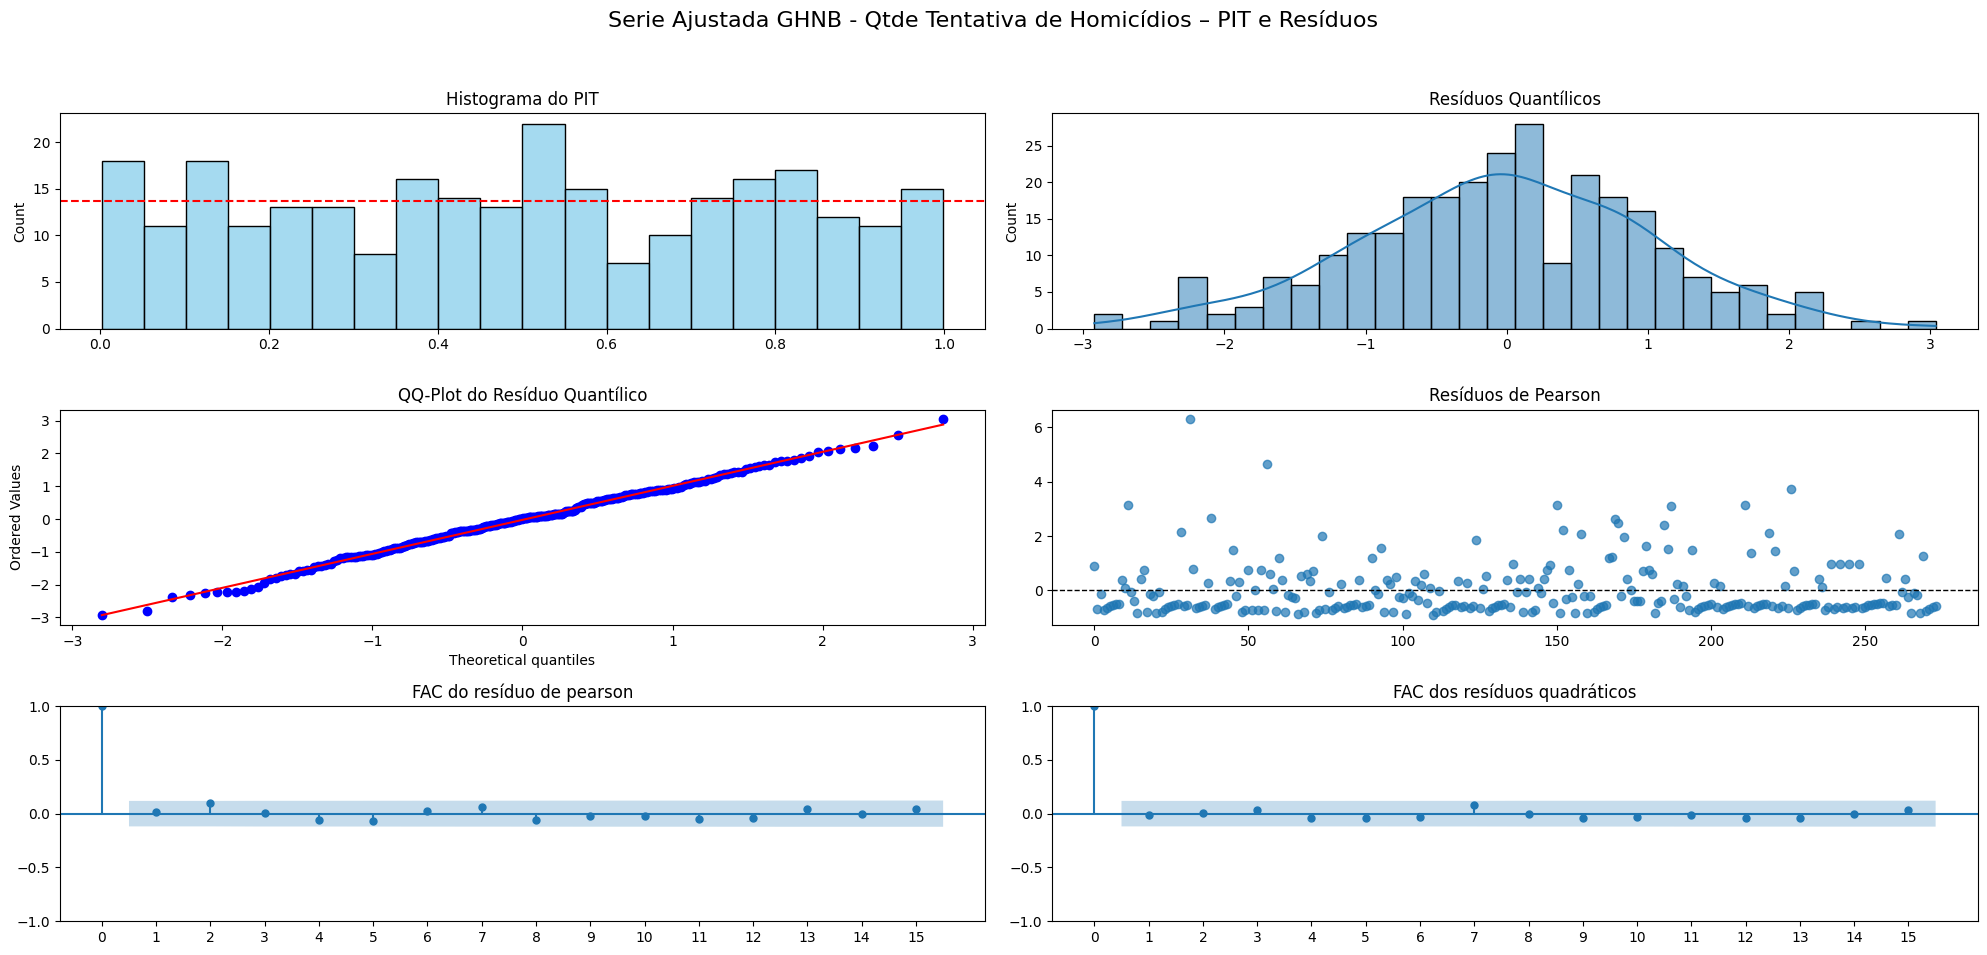

In [55]:
pit_ghnb, quant_resid_ghnb, pearson_resid_ghnb = diagnostics_ghnb(
    y=y_obs_serie_real,
    mu_t=mu_hat,
    pi_t=pi_hat,
    alpha_nb=params_dict["alpha"],
    title=f"Serie Ajustada GHNB - Qtde Tentativa de Homicídios"
)

In [56]:
# Obter os índices dos 5 maiores valores absolutos
top5_idx = np.argsort(np.abs(pearson_resid_ghnb))[-5:][::-1]  # ordena do maior pro menor

# Construir um DataFrame para visualização
df_top5 = pd.DataFrame({
    'Índice': top5_idx,
    'y_obs': y_obs_serie_real[top5_idx],
    'y_hat': yhat[top5_idx],
    'Pearson Residual': pearson_resid_ghnb[top5_idx]
})

# Visualizar os resultados
df_top5.reset_index(drop=True, inplace=True)

df_top5

,Índice,y_obs,y_hat,Pearson Residual
0,31,9,0.694203,6.293887
1,56,8,0.969004,4.656996
2,226,6,0.836521,3.720545
3,211,4,0.518270,3.161349
4,150,9,1.957413,3.160684


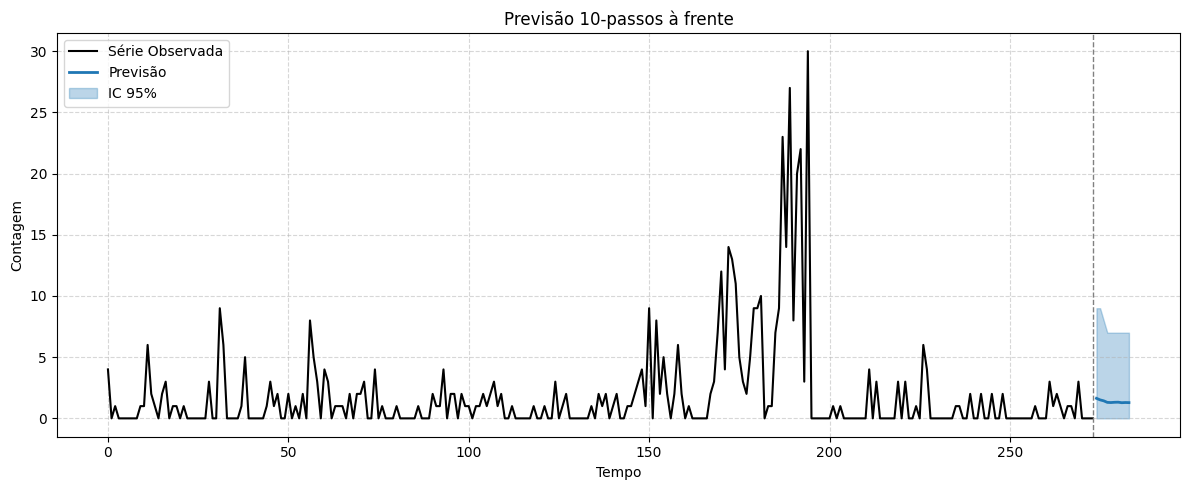

In [57]:
y_sim, y_mean, y_lo, y_hi = forecast_ghnb(
    y_obs=y_obs_serie_real, 
    **params_dict,
    k=10,
    n_sim=5000,
    seed=123
)

plot_forecast(y_obs_serie_real, y_mean, np.array([y_lo, y_hi]))